<a href="https://colab.research.google.com/github/amit-sikder/MIS444_Project_Ecommerce_Order_Cancellation_Risk_Prediction/blob/main/23204350_Amit_Sikder_MIS444_E_commerce_order_cancellation_risk__Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🛒 Predicting Order Cancellation Risk in E-Commerce Using Data Analytics

### Course: MIS444 — Predictive Analytics in Business

**Problem Type:** Classification — Predicting whether an order will be Cancelled or Normal

**Dataset Source:** Kaggle — [E-Commerce Data Dataset](https://www.kaggle.com/datasets/carrie1/ecommerce-data)

---

# Project Outline

1. Data Collection
2. Data Preprocessing & Cleaning
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Outlier Detection & Treatment
6. Feature Selection & Dataset Preparation
7. Data Encoding, Scaling & Train-Test Split
8. Handling Class Imbalance
9. Machine Learning Model Building
10. Model Optimization
11. Model Evaluation & Validation
12. Feature Importance Analysis
13. Order Cancellation Risk Prediction System
14. Business Insights & conclusion


# Data Collection

## Step 1: Import Libraries + Load Dataset + Basic Overview
**Why we are doing this step**

Before cleaning, reducing, or analyzing the dataset, we need to understand:
*  Whether the dataset loads correctly
*  How many rows and columns it has
*  What columns are available
*  What data types each column has
*  Whether the dataset has obvious missing values
*  What the first few records look like

This gives us the initial dataset overview, which we can write in the report before explaining why we reduce the dataset size.

In [ ]:
# ============================================================
# STEP 1: IMPORT LIBRARIES + LOAD DATASET + BASIC OVERVIEW
# Project: Predicting Order Cancellation Risk in E-Commerce
# Platform: Google Colab
# ============================================================

# ------------------------------------------------------------
# 1. Basic Data Handling Libraries
# Purpose:
# - pandas: load and manipulate dataset
# - numpy: numerical operations
# ------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 2. Visualization Libraries
# Purpose:
# - matplotlib: basic charts and graphs
# - seaborn: advanced statistical visualizations
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 3. Machine Learning Preparation Libraries
# Purpose:
# - train_test_split: split data into training and testing sets
# - GridSearchCV: tune model parameters during optimization
# - StandardScaler: scale numerical variables
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 4. Machine Learning Model Libraries
# Purpose:
# - Logistic Regression: baseline classification model
# - Decision Tree: interpretable classification model
# - Random Forest: ensemble model for stronger performance
# - KNN: distance-based classification model
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# ------------------------------------------------------------
# 5. Model Evaluation Libraries
# Purpose:
# - accuracy, precision, recall, F1, ROC-AUC: classification metrics
# - confusion matrix: shows correct and incorrect predictions
# - classification report: detailed model performance summary
# - ROC curve: visual model performance evaluation
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ------------------------------------------------------------
# 6. Warning Control
# Purpose:
# - Hide unnecessary warnings to keep notebook output clean
# ------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 7. Mount Google Drive
# Purpose:
# - Connect Google Colab with Google Drive
# - Allows loading the dataset directly from Drive
# ------------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')


# ------------------------------------------------------------
# 8. Load Dataset from Google Drive
# Purpose:
# - Read the e-commerce CSV file into a pandas DataFrame
# - encoding="ISO-8859-1" is used because this dataset contains
#   special characters in product descriptions
# ------------------------------------------------------------

file_path = "/content/drive/MyDrive/MIS444 26 Amit/Dataset/E-commerce data.csv"  # change path if your file is inside another folder

df = pd.read_csv(file_path, encoding="ISO-8859-1")


# ------------------------------------------------------------
# 9. Basic Dataset Overview
# Purpose:
# - Understand the initial structure of the dataset
# - Check rows, columns, data types, and sample records
# ------------------------------------------------------------

print("Dataset Loaded Successfully")
print("Dataset Shape (Rows, Columns):", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nDataset Information:")
df.info()

print("\nBasic Statistical Summary of Numerical Columns:")
display(df.describe())

print("\nBasic Summary of Categorical Columns:")
display(df.describe(include="object"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully
Dataset Shape (Rows, Columns): (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Last 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Basic Statistical Summary of Numerical Columns:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000



Basic Summary of Categorical Columns:


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


**Insight:**

1. Dataset Size Overview-

👉This is a large dataset of 541,909 rows and 8 columns

  * Good for real-world analysis
  * But heavy for:
    * plotting graphs
    * training models
    * running multiple experiments

2. Columns overview-

  * Mix of categorical + numerical + datetime
  * No direct target variable → we will create one later

3. Data types-

  * InvoiceDate is not datetime yet ❗
  * CustomerID has missing values(huge) ❗

4. Numerical summary

👉 Negative values exist
  
  * Negative quantity(Quantity) → returns/cancellations
  * Negative price (Unit Price)→ data issues or refunds

👉 This is EXACTLY what we need for: Order cancellation detection

5. Country distribution

  * Dataset is imbalanced geographically
  * Good for EDA later


# Step 2: Dataset Reduction Using Stratified Sampling

**This is large for Google Colab, especially when we do:**

* graphs
* preprocessing
* feature creation
* model training(mainly)
* optimization(mainly)

> So we will reduce it to 200,000 rows.

But because our project target is order cancellation, we should not sample randomly without control. Cancelled orders may be fewer than normal orders.

That is why we use stratified sampling.

**What stratified sampling does?**

👉 It keeps the same proportion of: *normal orders*, *cancelled orders* as much as possible in the reduced dataset.

> So the smaller dataset still represents the original dataset properly

In [ ]:
# ============================================================
# STEP 2: DATASET REDUCTION USING STRATIFIED SAMPLING
# ============================================================

# ------------------------------------------------------------
# 1. Create temporary target column for cancellation
# Purpose:
# - Invoice numbers starting with "C" represent cancelled transactions
# - This temporary target helps us perform stratified sampling
# ------------------------------------------------------------

df["Temp_Cancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)


# ------------------------------------------------------------
# 2. Check original cancellation distribution
# Purpose:
# - Understand the original proportion of normal and cancelled records
# ------------------------------------------------------------

print("Original Dataset Shape:", df.shape)

print("\nOriginal Cancellation Count:")
print(df["Temp_Cancelled"].value_counts())

print("\nOriginal Cancellation Percentage:")
print(df["Temp_Cancelled"].value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 3. Apply stratified sampling
# Purpose:
# - Reduce dataset size while preserving cancellation distribution
# - sample_size is set to 200,000 for efficient analysis in Google Colab
# ------------------------------------------------------------

sample_size = 200000

df_sampled, _ = train_test_split(
    df,
    train_size=sample_size,
    stratify=df["Temp_Cancelled"],
    random_state=42
)


# ------------------------------------------------------------
# 4. Check sampled dataset distribution
# Purpose:
# - Verify that the sampled dataset preserved the cancellation ratio
# ------------------------------------------------------------

print("\nSampled Dataset Shape:", df_sampled.shape)

print("\nSampled Cancellation Count:")
print(df_sampled["Temp_Cancelled"].value_counts())

print("\nSampled Cancellation Percentage:")
print(df_sampled["Temp_Cancelled"].value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 5. Drop temporary column after verification
# Purpose:
# - The temporary column was only used for sampling
# - We will create the final target variable properly later
# ------------------------------------------------------------

df_sampled = df_sampled.drop("Temp_Cancelled", axis=1)


# ------------------------------------------------------------
# 6. Reset index
# Purpose:
# - Clean row indexing after sampling
# ------------------------------------------------------------

df_sampled = df_sampled.reset_index(drop=True)


# ------------------------------------------------------------
# 7. Preview sampled dataset
# ------------------------------------------------------------

print("\nFinal Sampled Dataset Preview:")
display(df_sampled.head())

Original Dataset Shape: (541909, 9)

Original Cancellation Count:
Temp_Cancelled
0    532621
1      9288
Name: count, dtype: int64

Original Cancellation Percentage:
Temp_Cancelled
0    98.286059
1     1.713941
Name: proportion, dtype: float64

Sampled Dataset Shape: (200000, 9)

Sampled Cancellation Count:
Temp_Cancelled
0    196572
1      3428
Name: count, dtype: int64

Sampled Cancellation Percentage:
Temp_Cancelled
0    98.286
1     1.714
Name: proportion, dtype: float64

Final Sampled Dataset Preview:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,580983,22178,VICTORIAN GLASS HANGING T-LIGHT,2,12/6/2011 16:26,2.46,NaN,United Kingdom
1,554261,23100,SILVER BELLS TABLE DECORATION,2,5/23/2011 12:32,1.25,16033.0,United Kingdom
2,546950,22262,FELT EGG COSY CHICKEN,3,3/18/2011 11:24,0.85,16511.0,United Kingdom
3,559355,22215,CAKE STAND WHITE TWO TIER LACE,2,7/7/2011 18:14,8.50,17007.0,United Kingdom
4,539321,85103,SILVER T-LIGHT SETTING,1,12/16/2010 19:19,6.75,14723.0,United Kingdom


**Insight:**

The dataset shows *extreme class imbalanc*e, where only about **1.7%** of *transactions* are *cancelled*. This imbalance can *bias* predictive models toward the **majority class** (*non-cancelled orders*). Therefore, evaluation metrics such as *precision*, *recall*, and *F1-score* will be used instead of relying only on accuracy.


#Step 3: Data Preprocessing

## Step 3.1: Data Cleaning & Initial Preprocessing

**Why we are doing this step**

Before EDA and modeling, we need to check whether the sampled dataset has:

* Missing values
* Duplicate rows
* Incorrect data types
* Negative values
* Unusual transaction values

This is important because our dataset is real transaction data, and it contains *cancellations/returns*, *missing customer IDs*, and *possible pricing issues*.

Working dataset created successfully.
Shape: (200000, 8)

Missing Value Report:


,Missing Count,Missing Percentage
InvoiceNo,0,0.0000
StockCode,0,0.0000
Description,585,0.2925
Quantity,0,0.0000
InvoiceDate,0,0.0000
UnitPrice,0,0.0000
CustomerID,49903,24.9515
Country,0,0.0000


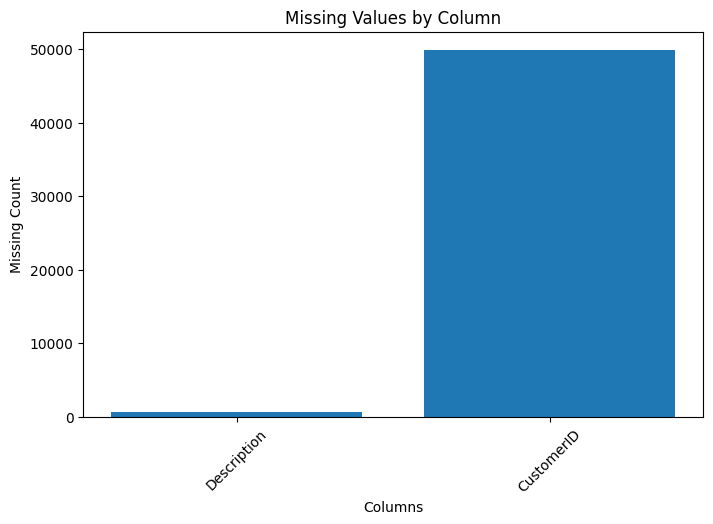


Duplicate Rows:
786

Data Types Before Conversion:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Data Types After InvoiceDate Conversion:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Negative Value Check:
Negative Quantity Count: 3946
Negative UnitPrice Count: 0

Zero Value Check:
Zero Quantity Count: 0
Zero UnitPrice Count: 975

Target Variable Created: Order_Cancelled

Order Cancellation Count:
Order_Cancelled
0    196572
1      3428
Name: count, dtype: int64

Order Cancellation Percentage:
Order_Cancelled
0    98.286
1     1.714
Name: proportion, dtype: float64


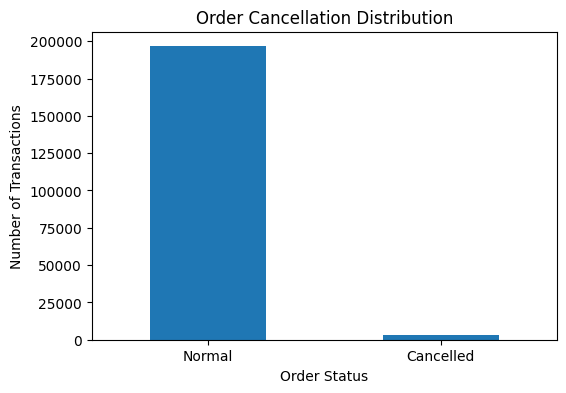


Preview of Working Dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Order_Cancelled
0,580983,22178,VICTORIAN GLASS HANGING T-LIGHT,2,2011-12-06 16:26:00,2.46,NaN,United Kingdom,0
1,554261,23100,SILVER BELLS TABLE DECORATION,2,2011-05-23 12:32:00,1.25,16033.0,United Kingdom,0
2,546950,22262,FELT EGG COSY CHICKEN,3,2011-03-18 11:24:00,0.85,16511.0,United Kingdom,0
3,559355,22215,CAKE STAND WHITE TWO TIER LACE,2,2011-07-07 18:14:00,8.50,17007.0,United Kingdom,0
4,539321,85103,SILVER T-LIGHT SETTING,1,2010-12-16 19:19:00,6.75,14723.0,United Kingdom,0


In [ ]:
# ============================================================
# STEP 3.1: INITIAL PREPROCESSING CHECK(Data Quality Assesment)
# What problems exist in the dataset?
# ============================================================


# ------------------------------------------------------------
# 1. Create a working copy
# Purpose:
# - Keep the sampled dataset unchanged
# - Perform cleaning on a separate DataFrame
# ------------------------------------------------------------

df_clean = df_sampled.copy()

print("Working dataset created successfully.")
print("Shape:", df_clean.shape)


# ------------------------------------------------------------
# 2. Check missing values
# Purpose:
# - Identify columns with missing data
# - Missing values affect analysis and model training
# ------------------------------------------------------------

missing_count = df_clean.isnull().sum()
missing_percent = (missing_count / len(df_clean)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

print("\nMissing Value Report:")
display(missing_report)


# ------------------------------------------------------------
# 3. Visualize missing values
# Purpose:
# - Show missingness clearly in graph form for report
# ------------------------------------------------------------

missing_report_nonzero = missing_report[missing_report["Missing Count"] > 0]

plt.figure(figsize=(8, 5))
plt.bar(missing_report_nonzero.index, missing_report_nonzero["Missing Count"])
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 4. Check duplicate rows
# Purpose:
# - Duplicate records can distort analysis and model learning
# ------------------------------------------------------------

duplicate_count = df_clean.duplicated().sum()

print("\nDuplicate Rows:")
print(duplicate_count)


# ------------------------------------------------------------
# 5. Check data types
# Purpose:
# - Identify columns that need type conversion
# - InvoiceDate should be datetime
# ------------------------------------------------------------

print("\nData Types Before Conversion:")
print(df_clean.dtypes)


# ------------------------------------------------------------
# 6. Convert InvoiceDate to datetime
# Purpose:
# - Required for extracting month, day, hour, weekday features later
# ------------------------------------------------------------

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

print("\nData Types After InvoiceDate Conversion:")
print(df_clean.dtypes)


# ------------------------------------------------------------
# 7. Check negative values
# Purpose:
# - Negative Quantity may indicate cancelled/returned orders
# - Negative UnitPrice may indicate data issue
# ------------------------------------------------------------

negative_quantity = (df_clean["Quantity"] < 0).sum()
negative_unitprice = (df_clean["UnitPrice"] < 0).sum()

print("\nNegative Value Check:")
print("Negative Quantity Count:", negative_quantity)
print("Negative UnitPrice Count:", negative_unitprice)


# ------------------------------------------------------------
# 8. Check zero values
# Purpose:
# - Zero price or zero quantity may need investigation
# ------------------------------------------------------------

zero_quantity = (df_clean["Quantity"] == 0).sum()
zero_unitprice = (df_clean["UnitPrice"] == 0).sum()

print("\nZero Value Check:")
print("Zero Quantity Count:", zero_quantity)
print("Zero UnitPrice Count:", zero_unitprice)


# ------------------------------------------------------------
# 9. Create target variable: Order_Cancelled
# Purpose:
# - Our project is classification
# - InvoiceNo starting with C means cancelled transaction
# ------------------------------------------------------------

df_clean["Order_Cancelled"] = df_clean["InvoiceNo"].astype(str).str.startswith("C").astype(int)

print("\nTarget Variable Created: Order_Cancelled")

print("\nOrder Cancellation Count:")
print(df_clean["Order_Cancelled"].value_counts())

print("\nOrder Cancellation Percentage:")
print(df_clean["Order_Cancelled"].value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 10. Cancellation distribution graph
# Purpose:
# - Show class imbalance visually
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
df_clean["Order_Cancelled"].value_counts().plot(kind="bar")
plt.title("Order Cancellation Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Normal", "Cancelled"], rotation=0)
plt.show()


# ------------------------------------------------------------
# 11. Basic cleaned dataset preview
# ------------------------------------------------------------

print("\nPreview of Working Dataset:")
display(df_clean.head())

**Insight:**

The dataset contains **missing values** in the *CustomerID* and *Description columns*, where CustomerID has approximately **25% missing values**. **Duplicate records** were also identified, which may **affect analysis accuracy**. The **InvoiceDate** variable was *converted* to **datetime format** to enable **time-based feature** extraction. **Negative values** were observed in the **Quantity column**, which *represent returned or cancelled transactions* and are important for defining the **target variable**. Additionally, **zero values** were found in the **UnitPrice column**. The dataset also exhibits significant **class imbalance**, with only about **1.7%** of **transactions being cancelled**.


👉**What we achieved in Step**

* Identified missing values
* ✅ Found duplicate records
* ✅Converted date correctly
* ✅ Understood negative values (critical for project)
* ✅ Created target variable
* ✅ Confirmed class imbalance

## Step 3.2: Data Cleaning and Treatment

**Why we are doing this step-**

This step prepares the dataset for *EDA*, *feature creation*, and *modeling*.

**From Step 3.1, we found:**

* CustomerID has many missing values
* Description has few missing values
* Duplicate rows exist
* UnitPrice has zero values
* Negative quantity values are important because they indicate cancellations returns

**We will now apply the cleaning decisions:**

* Remove duplicates
* Drop rows with missing Description
* Keep missing CustomerID but mark it using a new feature
* Investigate and handle zero UnitPrice
* Verify dataset after cleaning

> We will clean only *what is necessary* and preserve meaningful business information.

In [ ]:
# ============================================================
# STEP 3.2: DATA CLEANING AND Treatment
# How did we fix the problems?
# ============================================================


# ------------------------------------------------------------
# 1. Create another copy before cleaning
# Purpose:
# - Keep df_clean unchanged
# - Perform final cleaning on a new DataFrame
# ------------------------------------------------------------

df_preprocessed = df_clean.copy()

print("Dataset shape before cleaning:", df_preprocessed.shape)


# ------------------------------------------------------------
# 2. Remove duplicate rows
# Purpose:
# - Duplicate rows can overrepresent the same transaction
# - This may bias EDA and model learning
# ------------------------------------------------------------

duplicates_before = df_preprocessed.duplicated().sum()
print("\nDuplicate rows before removal:", duplicates_before)

df_preprocessed = df_preprocessed.drop_duplicates()

duplicates_after = df_preprocessed.duplicated().sum()
print("Duplicate rows after removal:", duplicates_after)

print("Shape after removing duplicates:", df_preprocessed.shape)


# ------------------------------------------------------------
# 3. Drop rows with missing Description
# Purpose:
# - Description has very few missing values
# - Product description is useful for product-level interpretation
# - Since missing percentage is very low, dropping these rows is safe
# ------------------------------------------------------------

missing_description_before = df_preprocessed["Description"].isnull().sum()
print("\nMissing Description before treatment:", missing_description_before)

df_preprocessed = df_preprocessed.dropna(subset=["Description"])

missing_description_after = df_preprocessed["Description"].isnull().sum()
print("Missing Description after treatment:", missing_description_after)

print("Shape after dropping missing Description rows:", df_preprocessed.shape)


# ------------------------------------------------------------
# 4. Handle missing CustomerID
# Purpose:
# - CustomerID has many missing values
# - Dropping them would remove a large part of the data
# - So we create a flag to capture missing customer identity
# ------------------------------------------------------------

missing_customer_before = df_preprocessed["CustomerID"].isnull().sum()
print("\nMissing CustomerID before treatment:", missing_customer_before)

df_preprocessed["CustomerID_Missing"] = df_preprocessed["CustomerID"].isnull().astype(int)

df_preprocessed["CustomerID"] = df_preprocessed["CustomerID"].fillna(0)

missing_customer_after = df_preprocessed["CustomerID"].isnull().sum()
print("Missing CustomerID after treatment:", missing_customer_after)

print("\nCustomerID Missing Flag Distribution:")
print(df_preprocessed["CustomerID_Missing"].value_counts())


# ------------------------------------------------------------
# 5. Investigate zero UnitPrice rows
# Purpose:
# - Zero UnitPrice may represent free items, promotions, or incorrect records
# - We check how many are cancelled vs normal
# ------------------------------------------------------------

zero_price_count = (df_preprocessed["UnitPrice"] == 0).sum()
print("\nZero UnitPrice Count:", zero_price_count)

print("\nZero UnitPrice by Order Cancellation:")
print(pd.crosstab(df_preprocessed["UnitPrice"] == 0, df_preprocessed["Order_Cancelled"]))


# ------------------------------------------------------------
# 6. Remove zero UnitPrice rows
# Purpose:
# - Zero price transactions do not represent normal sales value
# - They may distort Total Sales / Order Value calculations later
# - Since the count is small compared to dataset size, removing them is acceptable
# ------------------------------------------------------------

df_preprocessed = df_preprocessed[df_preprocessed["UnitPrice"] > 0]

print("\nShape after removing zero UnitPrice rows:", df_preprocessed.shape)


# ------------------------------------------------------------
# 7. Verify missing values after cleaning
# ------------------------------------------------------------

print("\nMissing Values After Cleaning:")
display(df_preprocessed.isnull().sum())


# ------------------------------------------------------------
# 8. Verify target distribution after cleaning
# Purpose:
# - Ensure cleaning did not damage cancellation class distribution
# ------------------------------------------------------------

print("\nOrder Cancellation Count After Cleaning:")
print(df_preprocessed["Order_Cancelled"].value_counts())

print("\nOrder Cancellation Percentage After Cleaning:")
print(df_preprocessed["Order_Cancelled"].value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 9. Final preview
# ------------------------------------------------------------

print("\nFinal Cleaned Dataset Preview:")
display(df_preprocessed.head())

print("\nFinal Cleaned Dataset Shape:", df_preprocessed.shape)

Dataset shape before cleaning: (200000, 9)

Duplicate rows before removal: 786
Duplicate rows after removal: 0
Shape after removing duplicates: (199214, 9)

Missing Description before treatment: 585
Missing Description after treatment: 0
Shape after dropping missing Description rows: (198629, 9)

Missing CustomerID before treatment: 49316
Missing CustomerID after treatment: 0

CustomerID Missing Flag Distribution:
CustomerID_Missing
0    149313
1     49316
Name: count, dtype: int64

Zero UnitPrice Count: 390

Zero UnitPrice by Order Cancellation:
Order_Cancelled       0     1
UnitPrice                    
False            194819  3420
True                390     0

Shape after removing zero UnitPrice rows: (198239, 10)

Missing Values After Cleaning:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Order_Cancelled,0
CustomerID_Missing,0



Order Cancellation Count After Cleaning:
Order_Cancelled
0    194819
1      3420
Name: count, dtype: int64

Order Cancellation Percentage After Cleaning:
Order_Cancelled
0    98.27481
1     1.72519
Name: proportion, dtype: float64

Final Cleaned Dataset Preview:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Order_Cancelled,CustomerID_Missing
0,580983,22178,VICTORIAN GLASS HANGING T-LIGHT,2,2011-12-06 16:26:00,2.46,0.0,United Kingdom,0,1
1,554261,23100,SILVER BELLS TABLE DECORATION,2,2011-05-23 12:32:00,1.25,16033.0,United Kingdom,0,0
2,546950,22262,FELT EGG COSY CHICKEN,3,2011-03-18 11:24:00,0.85,16511.0,United Kingdom,0,0
3,559355,22215,CAKE STAND WHITE TWO TIER LACE,2,2011-07-07 18:14:00,8.50,17007.0,United Kingdom,0,0
4,539321,85103,SILVER T-LIGHT SETTING,1,2010-12-16 19:19:00,6.75,14723.0,United Kingdom,0,0



Final Cleaned Dataset Shape: (198239, 10)


**Insight:**

**Duplicate records** were **removed** to prevent repeated transactions from biasing the analysis. **Rows with missing product descriptions** were **dropped** because the missing percentage was *very low*. However **CustomerID** had nearly **25% missing values**, *dropping these rows would remove a significant portion of the dataset*. Therefore, a new **binary feature** named **CustomerID_Missing** *created* to indicate *missing Customer Identity*, and **missing values** were **filled with 0**. This *preserves transaction records* while still allowing the model to capture whether unidentified customers behave differently.Additionally, **transactions with zero UnitPrice** were **removed** because they *did not represent meaningful sales transactions*. After cleaning, the dataset contained **198,239 records** with **no remaining missing values**.



**🔷 What we achieved so far-**

* ✅ Reduced dataset properly
* ✅ Created target variable
* ✅ Cleaned missing values
* ✅ Removed duplicates
* ✅ Preserved cancellation behavior
* ✅ Created meaningful business feature
* ✅ Prepared dataset for feature engineering and EDA

# Step 4: Feature Engineering

**We will create:**

* Total transaction value
* Invoice month
* Day
* Hour
* Weekday
* Absolute quantity
* Product diversity per invoice
* Possibly customer purchase behavior features

**🔷Why Feature Engineering-**


Raw columns alone are weak.

Feature engineering helps models understand:

* order size
* timing behavior
* transaction patterns
* customer behavior

This usually improves:

* business insights
* model performance

**Why we are doing this step**

Our original dataset has *only basic transaction columns*. To predict order cancellation risk, we need to *create* more *meaningful variable*s from the *existing data*.

Feature engineering helps us understand:

* order value
* order quantity
* purchase timing
* customer identification status
* cancellation behavior

>These features will later help with *EDA*, *feature *selection*, and *model building*.

In [ ]:
# ============================================================
# STEP 4: FEATURE ENGINEERING
# ============================================================


# ------------------------------------------------------------
# 1. Create a copy for feature engineering
# Purpose:
# - Keep cleaned dataset unchanged
# - Create new useful variables in a separate DataFrame
# ------------------------------------------------------------

df_features = df_preprocessed.copy()

print("Dataset shape before feature engineering:", df_features.shape)


# ------------------------------------------------------------
# 2. Create absolute quantity
# Purpose:
# - Cancelled orders have negative quantity
# - Absolute quantity helps measure the actual order size
# ------------------------------------------------------------

df_features["Abs_Quantity"] = df_features["Quantity"].abs()


# ------------------------------------------------------------
# 3. Create total transaction value
# Purpose:
# - Total value = quantity × unit price
# - Abs_Total_Value uses absolute quantity to avoid negative sales values
# ------------------------------------------------------------

df_features["Total_Value"] = df_features["Quantity"] * df_features["UnitPrice"]
df_features["Abs_Total_Value"] = df_features["Abs_Quantity"] * df_features["UnitPrice"]


# ------------------------------------------------------------
# 4. Extract date-based features
# Purpose:
# - Convert transaction date into useful time-based features
# - Helps analyze whether cancellations vary by month, day, or hour
# ------------------------------------------------------------

df_features["Invoice_Year"] = df_features["InvoiceDate"].dt.year
df_features["Invoice_Month"] = df_features["InvoiceDate"].dt.month
df_features["Invoice_Day"] = df_features["InvoiceDate"].dt.day
df_features["Invoice_Hour"] = df_features["InvoiceDate"].dt.hour
df_features["Invoice_Weekday"] = df_features["InvoiceDate"].dt.dayofweek


# ------------------------------------------------------------
# 5. Create invoice-level product count
# Purpose:
# - Count how many unique products are in each invoice
# - Larger/more complex orders may behave differently
# ------------------------------------------------------------

product_count = df_features.groupby("InvoiceNo")["StockCode"].nunique()
df_features["Unique_Products_Per_Invoice"] = df_features["InvoiceNo"].map(product_count)


# ------------------------------------------------------------
# 6. Create invoice-level total quantity
# Purpose:
# - Total quantity per invoice shows the size of the order
# ------------------------------------------------------------

invoice_quantity = df_features.groupby("InvoiceNo")["Abs_Quantity"].sum()
df_features["Total_Quantity_Per_Invoice"] = df_features["InvoiceNo"].map(invoice_quantity)


# ------------------------------------------------------------
# 7. Create invoice-level total value
# Purpose:
# - Total value per invoice shows the monetary size of the order
# ------------------------------------------------------------

invoice_value = df_features.groupby("InvoiceNo")["Abs_Total_Value"].sum()
df_features["Total_Value_Per_Invoice"] = df_features["InvoiceNo"].map(invoice_value)


# ------------------------------------------------------------
# 8. Preview engineered features
# ------------------------------------------------------------

print("Dataset shape after feature engineering:", df_features.shape)

print("\nNewly Created Columns:")
new_columns = [
    "Abs_Quantity",
    "Total_Value",
    "Abs_Total_Value",
    "Invoice_Year",
    "Invoice_Month",
    "Invoice_Day",
    "Invoice_Hour",
    "Invoice_Weekday",
    "Unique_Products_Per_Invoice",
    "Total_Quantity_Per_Invoice",
    "Total_Value_Per_Invoice"
]

print(new_columns)

display(df_features[new_columns + ["Order_Cancelled"]].head())


# ------------------------------------------------------------
# 9. Basic summary of new numerical features
# ------------------------------------------------------------

print("\nSummary of Engineered Features:")
display(df_features[new_columns].describe())

Dataset shape before feature engineering: (198239, 10)
Dataset shape after feature engineering: (198239, 21)

Newly Created Columns:
['Abs_Quantity', 'Total_Value', 'Abs_Total_Value', 'Invoice_Year', 'Invoice_Month', 'Invoice_Day', 'Invoice_Hour', 'Invoice_Weekday', 'Unique_Products_Per_Invoice', 'Total_Quantity_Per_Invoice', 'Total_Value_Per_Invoice']


,Abs_Quantity,Total_Value,Abs_Total_Value,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,Invoice_Weekday,Unique_Products_Per_Invoice,Total_Quantity_Per_Invoice,Total_Value_Per_Invoice,Order_Cancelled
0,2,4.92,4.92,2011,12,6,16,1,216,606,2873.85,0
1,2,2.50,2.50,2011,5,23,12,0,16,43,100.70,0
2,3,2.55,2.55,2011,3,18,11,4,28,58,166.70,0
3,2,17.00,17.00,2011,7,7,18,3,5,23,90.75,0
4,1,6.75,6.75,2010,12,16,19,3,13,29,69.50,0



Summary of Engineered Features:


,Abs_Quantity,Total_Value,Abs_Total_Value,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,Invoice_Weekday,Unique_Products_Per_Invoice,Total_Quantity_Per_Invoice,Total_Value_Per_Invoice
count,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000
mean,10.983152,17.992347,21.442357,2010.922114,7.551067,15.021237,13.068594,2.433088,41.087006,202.550189,518.045453
std,238.784733,272.258048,272.008076,0.267992,3.510519,8.665055,2.444032,1.843702,58.073957,420.802607,955.164340
min,1.000000,-77183.600000,0.001000,2010.000000,1.000000,1.000000,6.000000,0.000000,1.000000,1.000000,0.390000
25%,1.000000,3.750000,3.900000,2011.000000,5.000000,7.000000,11.000000,1.000000,9.000000,54.000000,104.410000
50%,3.000000,9.870000,9.900000,2011.000000,8.000000,15.000000,13.000000,2.000000,17.000000,113.000000,202.630000
75%,10.000000,17.400000,17.700000,2011.000000,11.000000,22.000000,15.000000,4.000000,44.000000,220.000000,534.200000
max,74215.000000,77183.600000,77183.600000,2011.000000,12.000000,31.000000,20.000000,6.000000,412.000000,74215.000000,77183.600000


**Insight:**

Feature engineering was performed to create additional business-relevant variables from the transaction dataset. Since cancelled orders contain, **negative quantities**, `Abs_Quantity` and `absolute transaction` value were created to represent the **actual number of items involved** in the **transaction** regardless of cancellation status. **Time-based features** such as `InvoiceDate`, `Invoice_Year`, `Invoice_Month`, `Invoice_Day`, `Invoice_Hour`, and `Invoice_Weekday` were extracted from **InvoiceDate**. **Invoice-level features** such as `total quantity`, `total order value`, and `number of unique products` were also created to better capture order behavior.



**🔷 What we achieved so far**

* ✅ Cleaned dataset
* ✅ Created target variable
* ✅ Created behavioral features
* ✅ Created time-based features
* ✅ Created order-level features
* ✅ Prepared dataset for deep EDA

# Step 5:Exploratory Data Analysis (EDA)

**This is where we discover:**

* what affects cancellations
* which patterns exist
* business insights
* correlations
* behavior differences

**🔷 EDA will include-**

 Cancellation behavior by:
* Country
* Month
* Hour
* Weekday

 Numerical analysis:
* Order value
* Quantity
* Product diversity

 Visualizations:
* Histograms
* Boxplots
* Bar charts
* Heatmaps

**Why we are doing EDA**

EDA helps us understand:

* how many orders are cancelled vs normal
* whether cancellation varies by country, month, hour, or weekday
* whether order value, quantity, and product diversity affect cancellation
* whether the dataset has imbalance or outlier patterns
* what business insights can be extracted before modeling

## Step 5.1: Target Variable Distribution

Order Cancellation Count:
Order_Cancelled
0    194819
1      3420
Name: count, dtype: int64

Order Cancellation Percentage:
Order_Cancelled
0    98.27481
1     1.72519
Name: proportion, dtype: float64


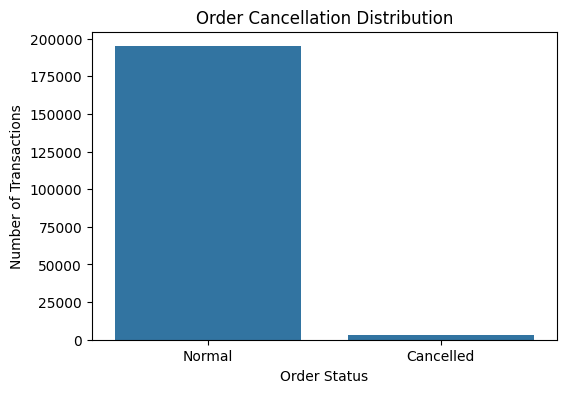

In [ ]:
# ============================================================
# STEP 5.1: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================


# ------------------------------------------------------------
# 1. Target Variable Distribution
# Purpose:
# - Understand how many orders are normal vs cancelled
# - Check class imbalance
# ------------------------------------------------------------

print("Order Cancellation Count:")
print(df_features["Order_Cancelled"].value_counts())

print("\nOrder Cancellation Percentage:")
print(df_features["Order_Cancelled"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x="Order_Cancelled", data=df_features)
plt.title("Order Cancellation Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Normal", "Cancelled"])
plt.show()

**Insight 5.1:**

This dataset is highly imbalanced:

* Normal orders: **98.27%**
* Cancelled orders: **1.73%**

> This means cancelled **orders are rare**. For modeling, **accuracy alone will not be enough** because a model may predict “Normal” most of the time and still get high accuracy. We should later focus on **precision**, **recall**, **F1-score**, and **ROC-AUC**.

## Step 5.2: Identify which countries have more normal/cancelled orders

Cancellation Percentage by Top Countries:


Order_Cancelled,0,1
Country,,
Australia,95.102041,4.897959
Belgium,98.293963,1.706037
EIRE,96.495251,3.504749
France,98.159126,1.840874
Germany,95.457127,4.542873
Netherlands,99.533256,0.466744
Portugal,98.844884,1.155116
Spain,98.268398,1.731602
Switzerland,98.421053,1.578947


<Figure size 1200x500 with 0 Axes>

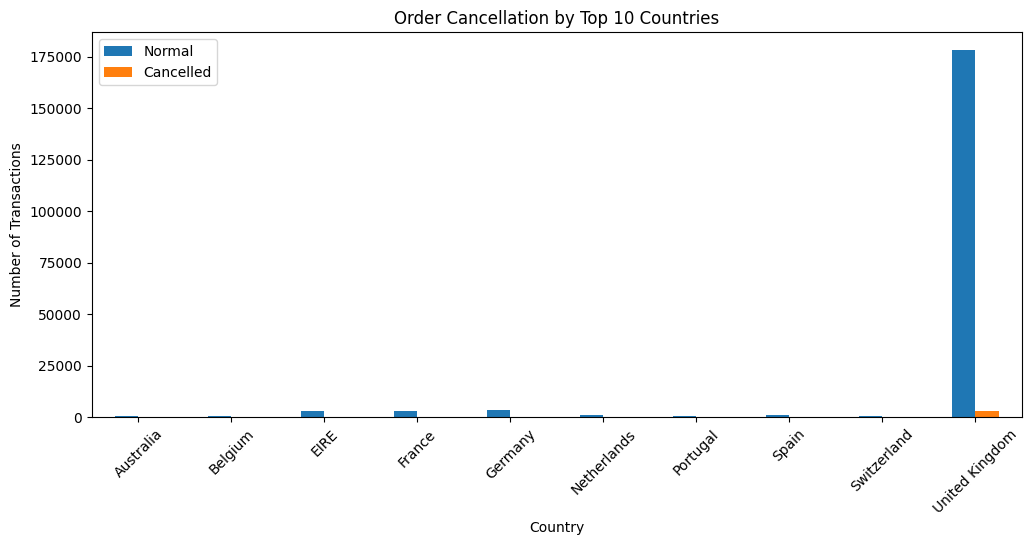

In [ ]:
# ------------------------------------------------------------
# Step 5.2: Cancellation by Country
# Purpose:
# - Identify which countries have more normal/cancelled orders
# - Useful for regional business insight
# ------------------------------------------------------------

top_countries = df_features["Country"].value_counts().head(10).index
country_data = df_features[df_features["Country"].isin(top_countries)]

country_cancel_table = pd.crosstab(
    country_data["Country"],
    country_data["Order_Cancelled"],
    normalize="index"
) * 100

print("Cancellation Percentage by Top Countries:")
display(country_cancel_table)

plt.figure(figsize=(12, 5))
pd.crosstab(country_data["Country"], country_data["Order_Cancelled"]).plot(
    kind="bar",
    figsize=(12, 5)
)
plt.title("Order Cancellation by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.legend(["Normal", "Cancelled"])
plt.show()

**Insight 5.2:**

Most transactions come from the **United Kingdom**, so the **UK dominates the dataset**.

Cancellation percentages among top countries vary. Some countries show higher cancellation percentages, such as:

* Australia: about **4.90%**
* EIRE: about **3.50%**
* Germany: about **4.54%**
* Netherlands: about **4.47%**

**Business insight:**

> Certain countries show higher cancellation rates, so country-level order monitoring may help reduce cancellation risk.

## Step 5.3: Check whether cancellation changes across months

Cancellation Percentage by Month:


Order_Cancelled,0,1
Invoice_Month,,
1,97.863746,2.136254
2,98.413780,1.586220
3,98.050975,1.949025
4,98.062976,1.937024
5,98.359450,1.640550
6,98.066667,1.933333
7,98.332754,1.667246
8,98.074086,1.925914
9,98.407540,1.592460


<Figure size 1000x500 with 0 Axes>

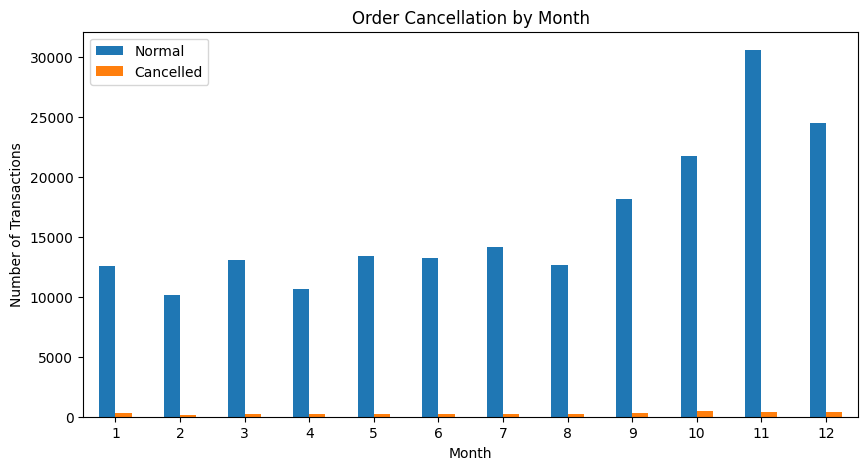

In [ ]:
# ------------------------------------------------------------
# Step 5.3: Cancellation by Month
# Purpose:
# - Check whether cancellation changes across months
# - Useful for seasonality/business planning
# ------------------------------------------------------------

month_cancel_table = pd.crosstab(
    df_features["Invoice_Month"],
    df_features["Order_Cancelled"],
    normalize="index"
) * 100

print("Cancellation Percentage by Month:")
display(month_cancel_table)

plt.figure(figsize=(10, 5))
pd.crosstab(df_features["Invoice_Month"], df_features["Order_Cancelled"]).plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Order Cancellation by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.legend(["Normal", "Cancelled"])
plt.show()

**Insight 5.3:**

**Cancellation rates** vary slightly by **month.**

**Higher cancellation months include:**

* January: about **2.14%**
* October: about **2.00%**
* April: about **1.94%**
* August: about **1.93%**

Business insight:

> Cancellation risk may have **seasonal patterns**. The business should *monitor* **months with relatively higher cancellation rates** and prepare customer support or order verification accordingly.

## Step 5.4: Check if cancellations vary by day of week

Cancellation Percentage by Weekday:


Order_Cancelled,0,1
Invoice_Weekday,,
0,98.318215,1.681785
1,98.279674,1.720326
2,98.104851,1.895149
3,97.743727,2.256273
4,98.304579,1.695421
6,99.273330,0.726670


<Figure size 800x500 with 0 Axes>

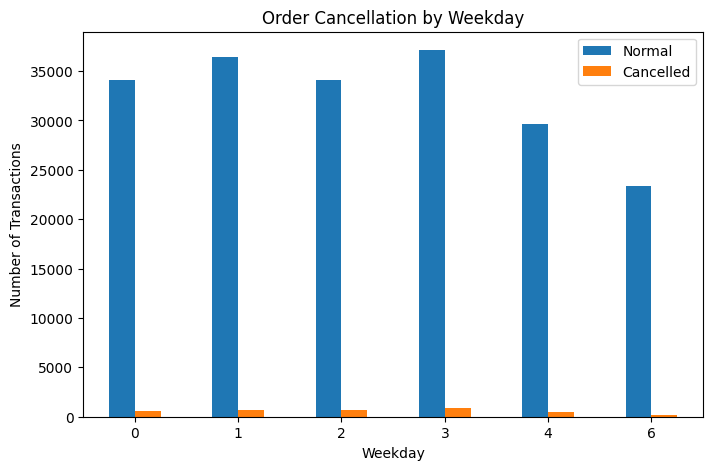

In [ ]:
# ------------------------------------------------------------
# Step 5.4: Cancellation by Weekday
# Purpose:
# - Check if cancellations vary by day of week
# - 0 = Monday, 6 = Sunday
# ------------------------------------------------------------

weekday_cancel_table = pd.crosstab(
    df_features["Invoice_Weekday"],
    df_features["Order_Cancelled"],
    normalize="index"
) * 100

print("Cancellation Percentage by Weekday:")
display(weekday_cancel_table)

plt.figure(figsize=(8, 5))
pd.crosstab(df_features["Invoice_Weekday"], df_features["Order_Cancelled"]).plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Order Cancellation by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.legend(["Normal", "Cancelled"])
plt.show()

**Insight 5.4:**

**Cancellation rates differ by weekday.**

**Highest cancellation rate appears on:**

* Thursday / weekday 3: about **2.26%**
* Wednesday / weekday 2: about **1.90%**

**Lowest appears on:**

* Sunday / weekday 6: about **0.73%**

**Business insight:**

> Some weekdays show **higher cancellation risk**, which may *help operational planning*.

## Step 5.5: Cancellation by Hour

Cancellation Percentage by Hour:


Order_Cancelled,0,1
Invoice_Hour,,
6,7.692308,92.307692
7,99.242424,0.757576
8,98.887553,1.112447
9,98.383172,1.616828
10,97.961564,2.038436
11,97.964328,2.035672
12,98.322742,1.677258
13,98.559873,1.440127
14,98.384092,1.615908


<Figure size 1000x500 with 0 Axes>

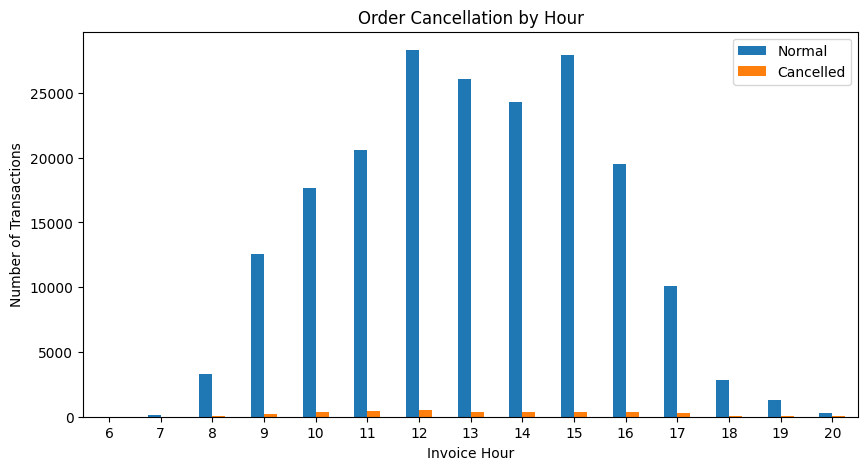

In [ ]:
# ------------------------------------------------------------
# Step 5.5: Cancellation by Hour
# Purpose:
# - Analyze whether order time affects cancellation behavior
# ------------------------------------------------------------

hour_cancel_table = pd.crosstab(
    df_features["Invoice_Hour"],
    df_features["Order_Cancelled"],
    normalize="index"
) * 100

print("Cancellation Percentage by Hour:")
display(hour_cancel_table)

plt.figure(figsize=(10, 5))
pd.crosstab(df_features["Invoice_Hour"], df_features["Order_Cancelled"]).plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Order Cancellation by Hour")
plt.xlabel("Invoice Hour")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.legend(["Normal", "Cancelled"])
plt.show()

**Insight 5.5:**

Cancellation rates are much **higher** at **certain hour**s.

**Notable higher cancellation rates:**

* `6 AM: about 92.31%`
* `20:00 / 8 PM: about 7.26%`
* `19:00 / 7 PM: about 5.30%`

**Important caution:**

> The 6 AM result may be misleading if the number of transactions at that time is very small. We should verify transaction counts before making a strong claim.

**Business insight:**

> *Late-hour transactions* may show **higher cancellation risk** and should be reviewed more carefully.

## Step 5.6: Order Value Comparison

Average Abs Total Value by Cancellation Status:


,Abs_Total_Value
Order_Cancelled,
0,20.063485
1,99.989260


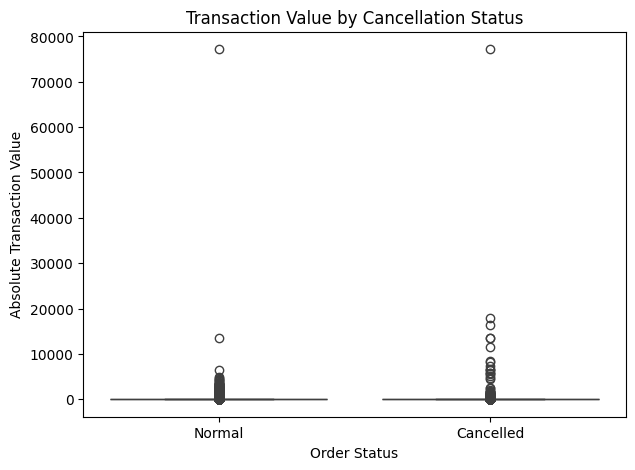

In [ ]:
# ------------------------------------------------------------
# step 5.6: Order Value Comparison
# Purpose:
# - Compare transaction value between normal and cancelled orders
# - Helps identify if high-value orders are more risky
# ------------------------------------------------------------

print("Average Abs Total Value by Cancellation Status:")
display(df_features.groupby("Order_Cancelled")["Abs_Total_Value"].mean())

plt.figure(figsize=(7, 5))
sns.boxplot(x="Order_Cancelled", y="Abs_Total_Value", data=df_features)
plt.title("Transaction Value by Cancellation Status")
plt.xlabel("Order Status")
plt.ylabel("Absolute Transaction Value")
plt.xticks([0, 1], ["Normal", "Cancelled"])
plt.show()

**Insight 5.6:**

**Average absolute transaction value:**

* `Normal orders: about 20.06`
* `Cancelled orders: about 99.99`

Cancelled transactions have much **higher average transaction value**.

**Business insight:**

> **Higher-value transactions** appear more likely to be *cancelled* or *returned*. The business should **monitor high-value orders** before processing.

## Step 5.7: Quantity Comparison

Average Absolute Quantity by Cancellation Status:


,Abs_Quantity
Order_Cancelled,
0,10.592704
1,33.224854


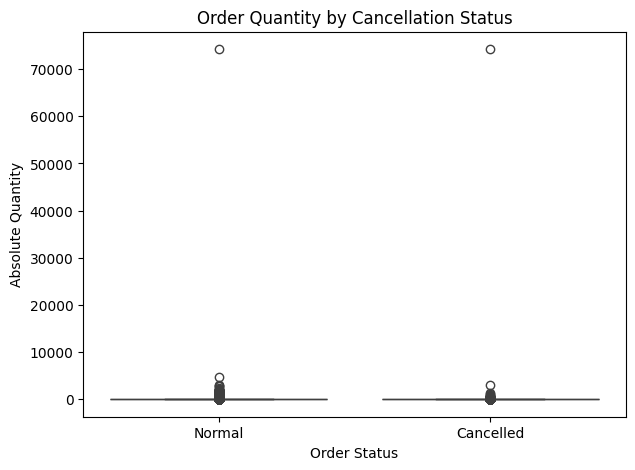

In [ ]:
# ------------------------------------------------------------
# Step 5.7: Quantity Comparison
# Purpose:
# - Compare order quantity between normal and cancelled transactions
# - Helps identify if larger quantity orders are more likely to cancel
# ------------------------------------------------------------

print("Average Absolute Quantity by Cancellation Status:")
display(df_features.groupby("Order_Cancelled")["Abs_Quantity"].mean())

plt.figure(figsize=(7, 5))
sns.boxplot(x="Order_Cancelled", y="Abs_Quantity", data=df_features)
plt.title("Order Quantity by Cancellation Status")
plt.xlabel("Order Status")
plt.ylabel("Absolute Quantity")
plt.xticks([0, 1], ["Normal", "Cancelled"])
plt.show()

**Insight 5.7:**

**Average absolute quantity:**

* `Normal orders: about 10.59`
* `Cancelled orders: about 33.22`

Cancelled transactions involve larger quantities on average.

**Business insight:**

> **Larger quantity orders** have **higher cancellation risk**. *Bulk orders may need additional verification*.

## Step 5.8: Invoice-Level Total Value Comparison

Average Total Invoice Value by Cancellation Status:


,Total_Value_Per_Invoice
Order_Cancelled,
0,524.335650
1,159.726792


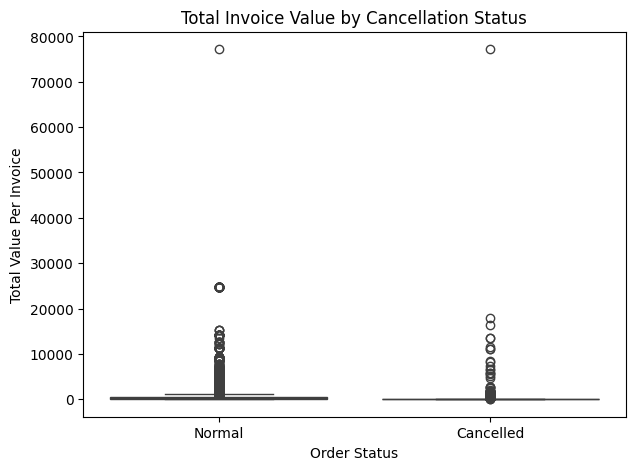

In [ ]:
# ------------------------------------------------------------
# Step 5.8: Invoice-Level Total Value Comparison
# Purpose:
# - Compare total invoice value for normal vs cancelled transactions
# ------------------------------------------------------------

print("Average Total Invoice Value by Cancellation Status:")
display(df_features.groupby("Order_Cancelled")["Total_Value_Per_Invoice"].mean())

plt.figure(figsize=(7, 5))
sns.boxplot(x="Order_Cancelled", y="Total_Value_Per_Invoice", data=df_features)
plt.title("Total Invoice Value by Cancellation Status")
plt.xlabel("Order Status")
plt.ylabel("Total Value Per Invoice")
plt.xticks([0, 1], ["Normal", "Cancelled"])
plt.show()

**Insight 5.8:**

**Average total invoice value:**

* `Normal orders: about 524.34`
* `Cancelled orders: about 159.73`

This is interesting because ***individual cancelled transaction values*** are **higher**, but **total invoice value** is **lower** for **cancelled invoices**.

**Possible interpretation:**

> **Cancelled invoices** may involve **fewer product lines** or **smaller invoice-level totals**, *even if individual cancelled items are high value*.

## Step 5.9: Unique Products Per Invoice

Average Unique Products per Invoice by Cancellation Status:


,Unique_Products_Per_Invoice
Order_Cancelled,
0,41.744666
1,3.623684


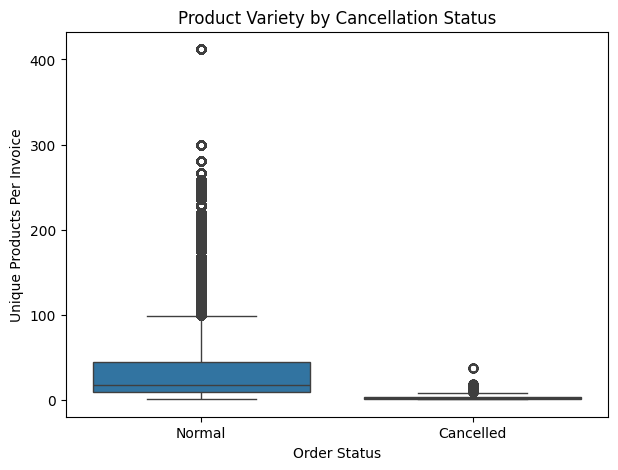

In [ ]:
# ------------------------------------------------------------
# Step 5.9: Unique Products Per Invoice
# Purpose:
# - Check if complex/multi-product orders are more likely to cancel
# ------------------------------------------------------------

print("Average Unique Products per Invoice by Cancellation Status:")
display(df_features.groupby("Order_Cancelled")["Unique_Products_Per_Invoice"].mean())

plt.figure(figsize=(7, 5))
sns.boxplot(x="Order_Cancelled", y="Unique_Products_Per_Invoice", data=df_features)
plt.title("Product Variety by Cancellation Status")
plt.xlabel("Order Status")
plt.ylabel("Unique Products Per Invoice")
plt.xticks([0, 1], ["Normal", "Cancelled"])
plt.show()

**Insight 5.9:**

**Average unique products per invoice:**

* `Normal orders: about 41.74`
* `Cancelled orders: about 3.62`

*Cancelled orders* usually involve *fewer unique products*.

**Business insight:**

> Orders with *fewer product types* may have **higher cancellation risk** compared to large multi-product orders.

## Step 5.10: CustomerID Missing vs Cancellation

Cancellation Percentage by CustomerID Missing Status:


Order_Cancelled,0,1
CustomerID_Missing,,
0,97.801101,2.198899
1,99.720048,0.279952


<Figure size 600x400 with 0 Axes>

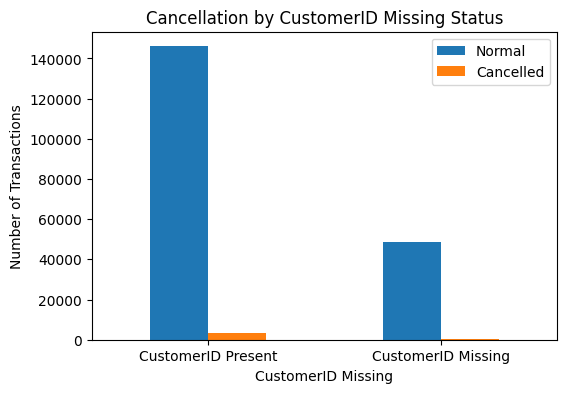

In [ ]:
# ------------------------------------------------------------
# Step 5.10: CustomerID Missing vs Cancellation
# Purpose:
# - Check whether anonymous/unknown customers behave differently
# ------------------------------------------------------------

customer_missing_table = pd.crosstab(
    df_features["CustomerID_Missing"],
    df_features["Order_Cancelled"],
    normalize="index"
) * 100

print("Cancellation Percentage by CustomerID Missing Status:")
display(customer_missing_table)

plt.figure(figsize=(6, 4))
pd.crosstab(df_features["CustomerID_Missing"], df_features["Order_Cancelled"]).plot(
    kind="bar",
    figsize=(6, 4)
)
plt.title("Cancellation by CustomerID Missing Status")
plt.xlabel("CustomerID Missing")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["CustomerID Present", "CustomerID Missing"], rotation=0)
plt.legend(["Normal", "Cancelled"])
plt.show()

**Insight 5.10:**

**Cancellation rate:**

* `CustomerID present: about 2.20%`
* `CustomerID missing: about 0.28%`

**Business insight:**

> **Registered** or **identifiable** customers show a **higher cancellation percentage** than missing CustomerID transactions. *This may suggest that most cancellation records are linked to known customers.*


This also justifies keeping the CustomerID_Missing feature.

## Step 5.11: Top Cancelled Products

Top 10 Cancelled Products:


,count
Description,
Manual,97
REGENCY CAKESTAND 3 TIER,63
POSTAGE,38
JAM MAKING SET WITH JARS,31
SET OF 3 CAKE TINS PANTRY DESIGN,27
ROSES REGENCY TEACUP AND SAUCER,25
Discount,24
STRAWBERRY CERAMIC TRINKET BOX,23
LUNCH BAG RED RETROSPOT,20


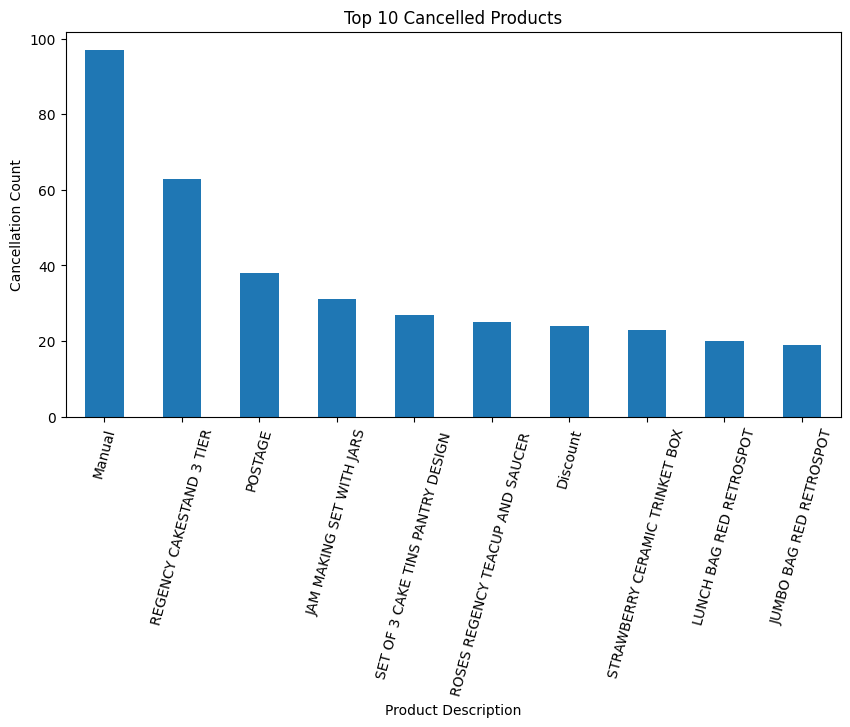

In [ ]:
# ------------------------------------------------------------
# Step 5.11: Top Cancelled Products
# Purpose:
# - Identify products most frequently involved in cancellations
# ------------------------------------------------------------

cancelled_products = df_features[df_features["Order_Cancelled"] == 1]

top_cancelled_products = cancelled_products["Description"].value_counts().head(10)

print("Top 10 Cancelled Products:")
display(top_cancelled_products)

plt.figure(figsize=(10, 5))
top_cancelled_products.plot(kind="bar")
plt.title("Top 10 Cancelled Products")
plt.xlabel("Product Description")
plt.ylabel("Cancellation Count")
plt.xticks(rotation=75)
plt.show()

**Insight 5.11:**

Most frequently cancelled products include:

* Manual
* Regency Cakestand 3 Tier
* Postage
* Jam Making Set With Jars
* Set of 3 Cake Tins Pantry Design

**Business insight:**

> Specific products are repeatedly involved in cancellations. The business should **inspect** these products for **issues** such as `pricing errors`, `shipping problems`, `stock issues`, or `customer dissatisfaction`.

## Step 5.12: Correlation Heatmap

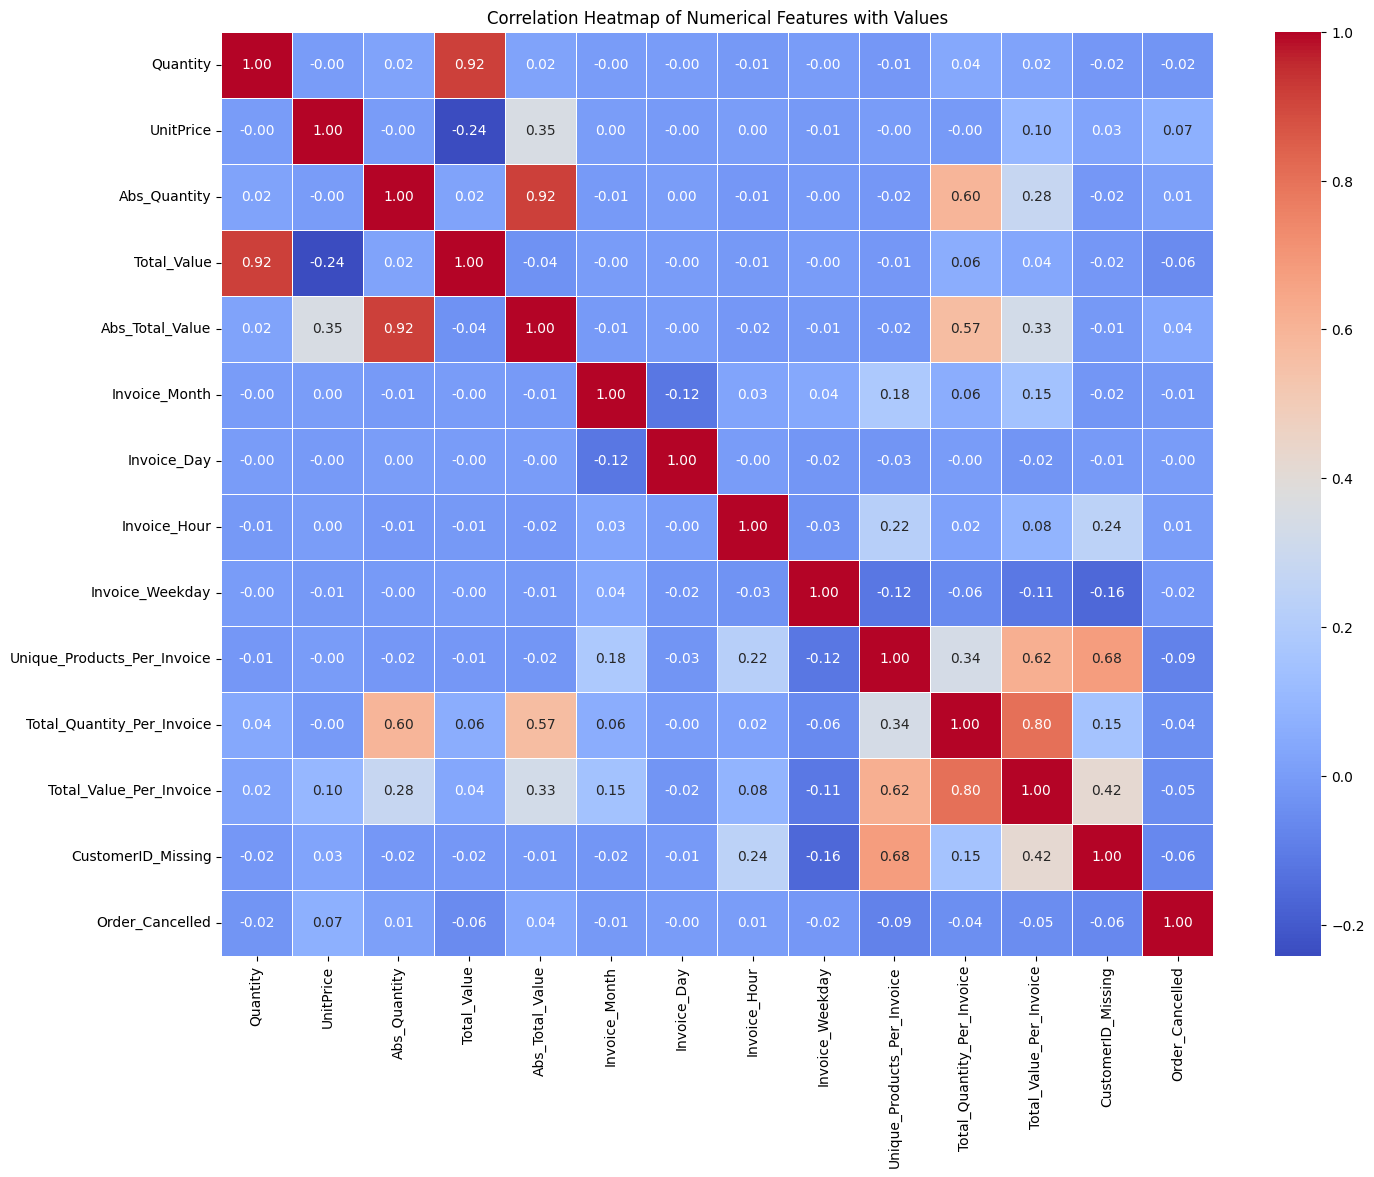

Correlation with Order_Cancelled:


,Order_Cancelled
Order_Cancelled,1.000000
UnitPrice,0.071000
Abs_Total_Value,0.038260
Abs_Quantity,0.012341
Invoice_Hour,0.005158
Invoice_Day,-0.002744
Invoice_Month,-0.010789
Invoice_Weekday,-0.015217
Quantity,-0.023889
Total_Quantity_Per_Invoice,-0.043166


In [ ]:
# ------------------------------------------------------------
# Step 5.12: Correlation Heatmap
# Purpose:
# - Understand relationship between numerical variables
# - Helps prepare for feature selection
# ------------------------------------------------------------

numeric_features_for_corr = [
    "Quantity",
    "UnitPrice",
    "Abs_Quantity",
    "Total_Value",
    "Abs_Total_Value",
    "Invoice_Month",
    "Invoice_Day",
    "Invoice_Hour",
    "Invoice_Weekday",
    "Unique_Products_Per_Invoice",
    "Total_Quantity_Per_Invoice",
    "Total_Value_Per_Invoice",
    "CustomerID_Missing",
    "Order_Cancelled"
]

corr_matrix = df_features[numeric_features_for_corr].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,          # shows numbers inside boxes
    fmt=".2f",           # shows values up to 2 decimal places
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Correlation Heatmap of Numerical Features with Values")
plt.show()

print("Correlation with Order_Cancelled:")
display(corr_matrix["Order_Cancelled"].sort_values(ascending=False))

**Insight 5.12:**

**The strongest positive correlation with Order_Cancelled is:**

* `UnitPrice: 0.07`
* `Abs_Total_Value: 0.04`
* `Abs_Quantity: 0.01`


**The strongest negative correlations are:**

* `Unique_Products_Per_Invoice: -0.09`
* `CustomerID_Missing: -0.06`
* `Total_Value: -0.06`
* `Total_Value_Per_Invoice: -0.05`

**Interpretation**

Most correlations with cancellation are **weak**. This means *cancellation risk is not explained by one single numeric feature*. Instead, it likely depends on a combination of features such as:

* `product type`
* `country`
* `order value`
* `quantity`
* `customer identification`
* `time features`

This supports using machine learning models rather than relying only on simple correlation.

#Step 6: Outlier Detection And Treatment

**Why we are doing this step?**

From your EDA boxplots, we saw extreme values in:

`Quantity`, `Abs_Quantity`, `Total_Value`, `Abs_Total_Value`, `Total_Quantity_Per_Invoice`, `Total_Value_Per_Invoice`, `Unique_Products_Per_Invoice`

**Outliers matter because they can:**

* distort averages
* affect scaling
* influence models
* make graphs hard to interpret

But in e-commerce, outliers may also represent real business behavior, such as ***bulk orders***. So we should **cap extreme values**, *not blindly delete them*.


**Parameters used**

`Q1`

25th percentile.

`Q3`

75th percentile.

`IQR`

Interquartile Range: `IQR = Q3 - Q1`

Lower bound: `Q1 - 1.5 × IQR`

Upper bound: `Q3 + 1.5 × IQR`

Values outside this range are considered outliers.

**Capping**

Instead of deleting outliers, extreme values are replaced with boundary values.

##Step 6.1: Select Numerical Columns for Outlier Analysis

**Why this step?**

We select **numerical columns** where *extreme transaction values may exist*, such as **quantity**, **price**, and **total order value**.

In [ ]:
# ============================================================
# STEP 6.1: SELECT NUMERICAL COLUMNS FOR OUTLIER ANALYSIS
# ============================================================

df_outlier = df_features.copy()

outlier_cols = [
    "Quantity",
    "Abs_Quantity",
    "UnitPrice",
    "Total_Value",
    "Abs_Total_Value",
    "Unique_Products_Per_Invoice",
    "Total_Quantity_Per_Invoice",
    "Total_Value_Per_Invoice"
]

print("Dataset shape before outlier analysis:", df_outlier.shape)
print("Columns selected for outlier analysis:")
print(outlier_cols)

Dataset shape before outlier analysis: (198239, 21)
Columns selected for outlier analysis:
['Quantity', 'Abs_Quantity', 'UnitPrice', 'Total_Value', 'Abs_Total_Value', 'Unique_Products_Per_Invoice', 'Total_Quantity_Per_Invoice', 'Total_Value_Per_Invoice']


##Step 6.2: Outlier Detection Using IQR Method

**Why this step?**

The IQR method *identifies* unusually **low or high values**. This helps us understand *which columns contain extreme values before treatment*.

In [ ]:
# ============================================================
# STEP 6.2: OUTLIER DETECTION USING IQR METHOD
# ============================================================

def count_outliers_iqr(data, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()

        outlier_summary[col] = {
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": outlier_count,
            "Outlier Percentage": (outlier_count / len(data)) * 100
        }

    return pd.DataFrame(outlier_summary).T


outlier_report_before = count_outliers_iqr(df_outlier, outlier_cols)

print("Outlier Report Before Treatment:")
display(outlier_report_before)

Outlier Report Before Treatment:


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
Quantity,1.00,10.00,9.00,-12.500,23.500,21196.0,10.692144
Abs_Quantity,1.00,10.00,9.00,-12.500,23.500,21103.0,10.645231
UnitPrice,1.25,4.13,2.88,-3.070,8.450,14581.0,7.355263
Total_Value,3.75,17.40,13.65,-16.725,37.875,16794.0,8.471592
Abs_Total_Value,3.90,17.70,13.80,-16.800,38.400,16127.0,8.135130
Unique_Products_Per_Invoice,9.00,44.00,35.00,-43.500,96.500,23513.0,11.860936
Total_Quantity_Per_Invoice,54.00,220.00,166.00,-195.000,469.000,19092.0,9.630799
Total_Value_Per_Invoice,104.41,534.20,429.79,-540.275,1178.885,21944.0,11.069467


##Step 6.3: Visualize Outliers Before Treatment

**Why this step?**

Boxplots visually **show extreme values**. *This makes the preprocessing evidence clear in the report.*

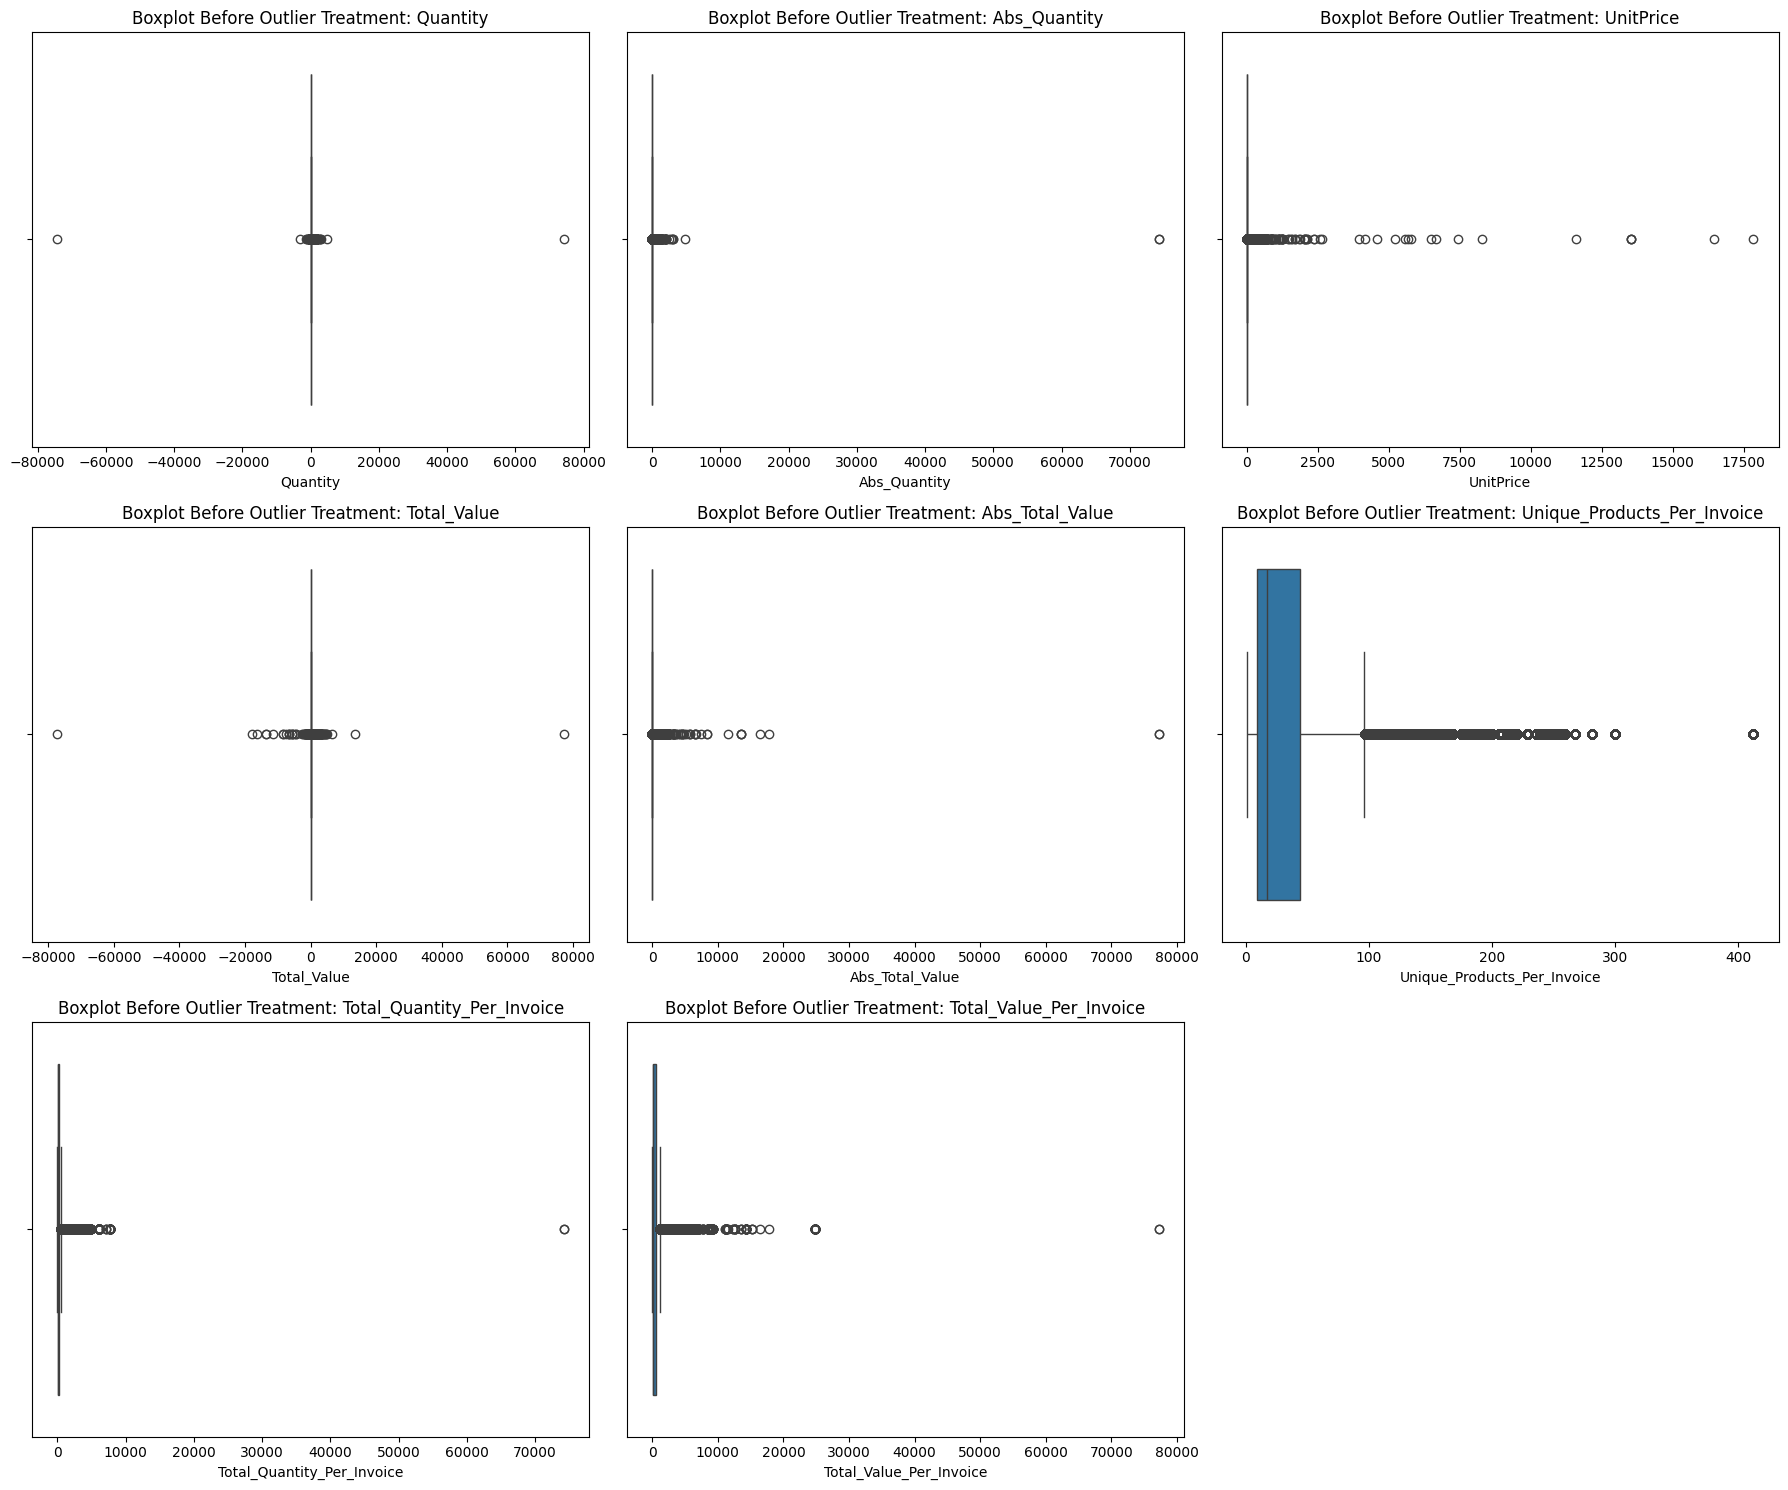

In [ ]:
# ============================================================
# STEP 6.3: VISUALIZE OUTLIERS BEFORE TREATMENT
# ============================================================

# Determine the number of rows and columns for the subplot grid
num_cols = len(outlier_cols)
num_rows = math.ceil(num_cols / 3)  # Use 3 columns per row for a 3x3 or 4x4-like layout

plt.figure(figsize=(18, 5 * num_rows))
for i, col in enumerate(outlier_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(x=df_outlier[col])
    plt.title(f"Boxplot Before Outlier Treatment: {col}")
    plt.xlabel(col)
plt.tight_layout()
plt.show()

##Step 6.4: Treat Outliers Using Capping

**Why this step?**

We cap outliers instead of deleting them because extreme values may represent real business cases, such as **bulk orders** or **high-value transaction**s.

In [ ]:
# ============================================================
# STEP 6.4: OUTLIER TREATMENT USING CAPPING
# ============================================================

for col in outlier_cols:
    Q1 = df_outlier[col].quantile(0.25)
    Q3 = df_outlier[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_outlier[col] = np.where(df_outlier[col] < lower_bound, lower_bound, df_outlier[col])
    df_outlier[col] = np.where(df_outlier[col] > upper_bound, upper_bound, df_outlier[col])

print("Outlier treatment completed using capping method.")

Outlier treatment completed using capping method.


##Step 6.5: Outlier Report After Treatment

**Why this step?**

This **verifies** whether the **extreme values** *were controlled* a**fter treatment**.

In [ ]:
# ============================================================
# STEP 6.5: OUTLIER REPORT AFTER TREATMENT
# ============================================================

outlier_report_after = count_outliers_iqr(df_outlier, outlier_cols)

print("Outlier Report After Treatment:")
display(outlier_report_after)

Outlier Report After Treatment:


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
Quantity,1.00,10.00,9.00,-12.500,23.500,0.0,0.0
Abs_Quantity,1.00,10.00,9.00,-12.500,23.500,0.0,0.0
UnitPrice,1.25,4.13,2.88,-3.070,8.450,0.0,0.0
Total_Value,3.75,17.40,13.65,-16.725,37.875,0.0,0.0
Abs_Total_Value,3.90,17.70,13.80,-16.800,38.400,0.0,0.0
Unique_Products_Per_Invoice,9.00,44.00,35.00,-43.500,96.500,0.0,0.0
Total_Quantity_Per_Invoice,54.00,220.00,166.00,-195.000,469.000,0.0,0.0
Total_Value_Per_Invoice,104.41,534.20,429.79,-540.275,1178.885,0.0,0.0


##Step 6.6: Visualize Outliers After Treatment

**Why this step?**

This allows **before-and-after comparison** and shows that preprocessing improved the dataset.

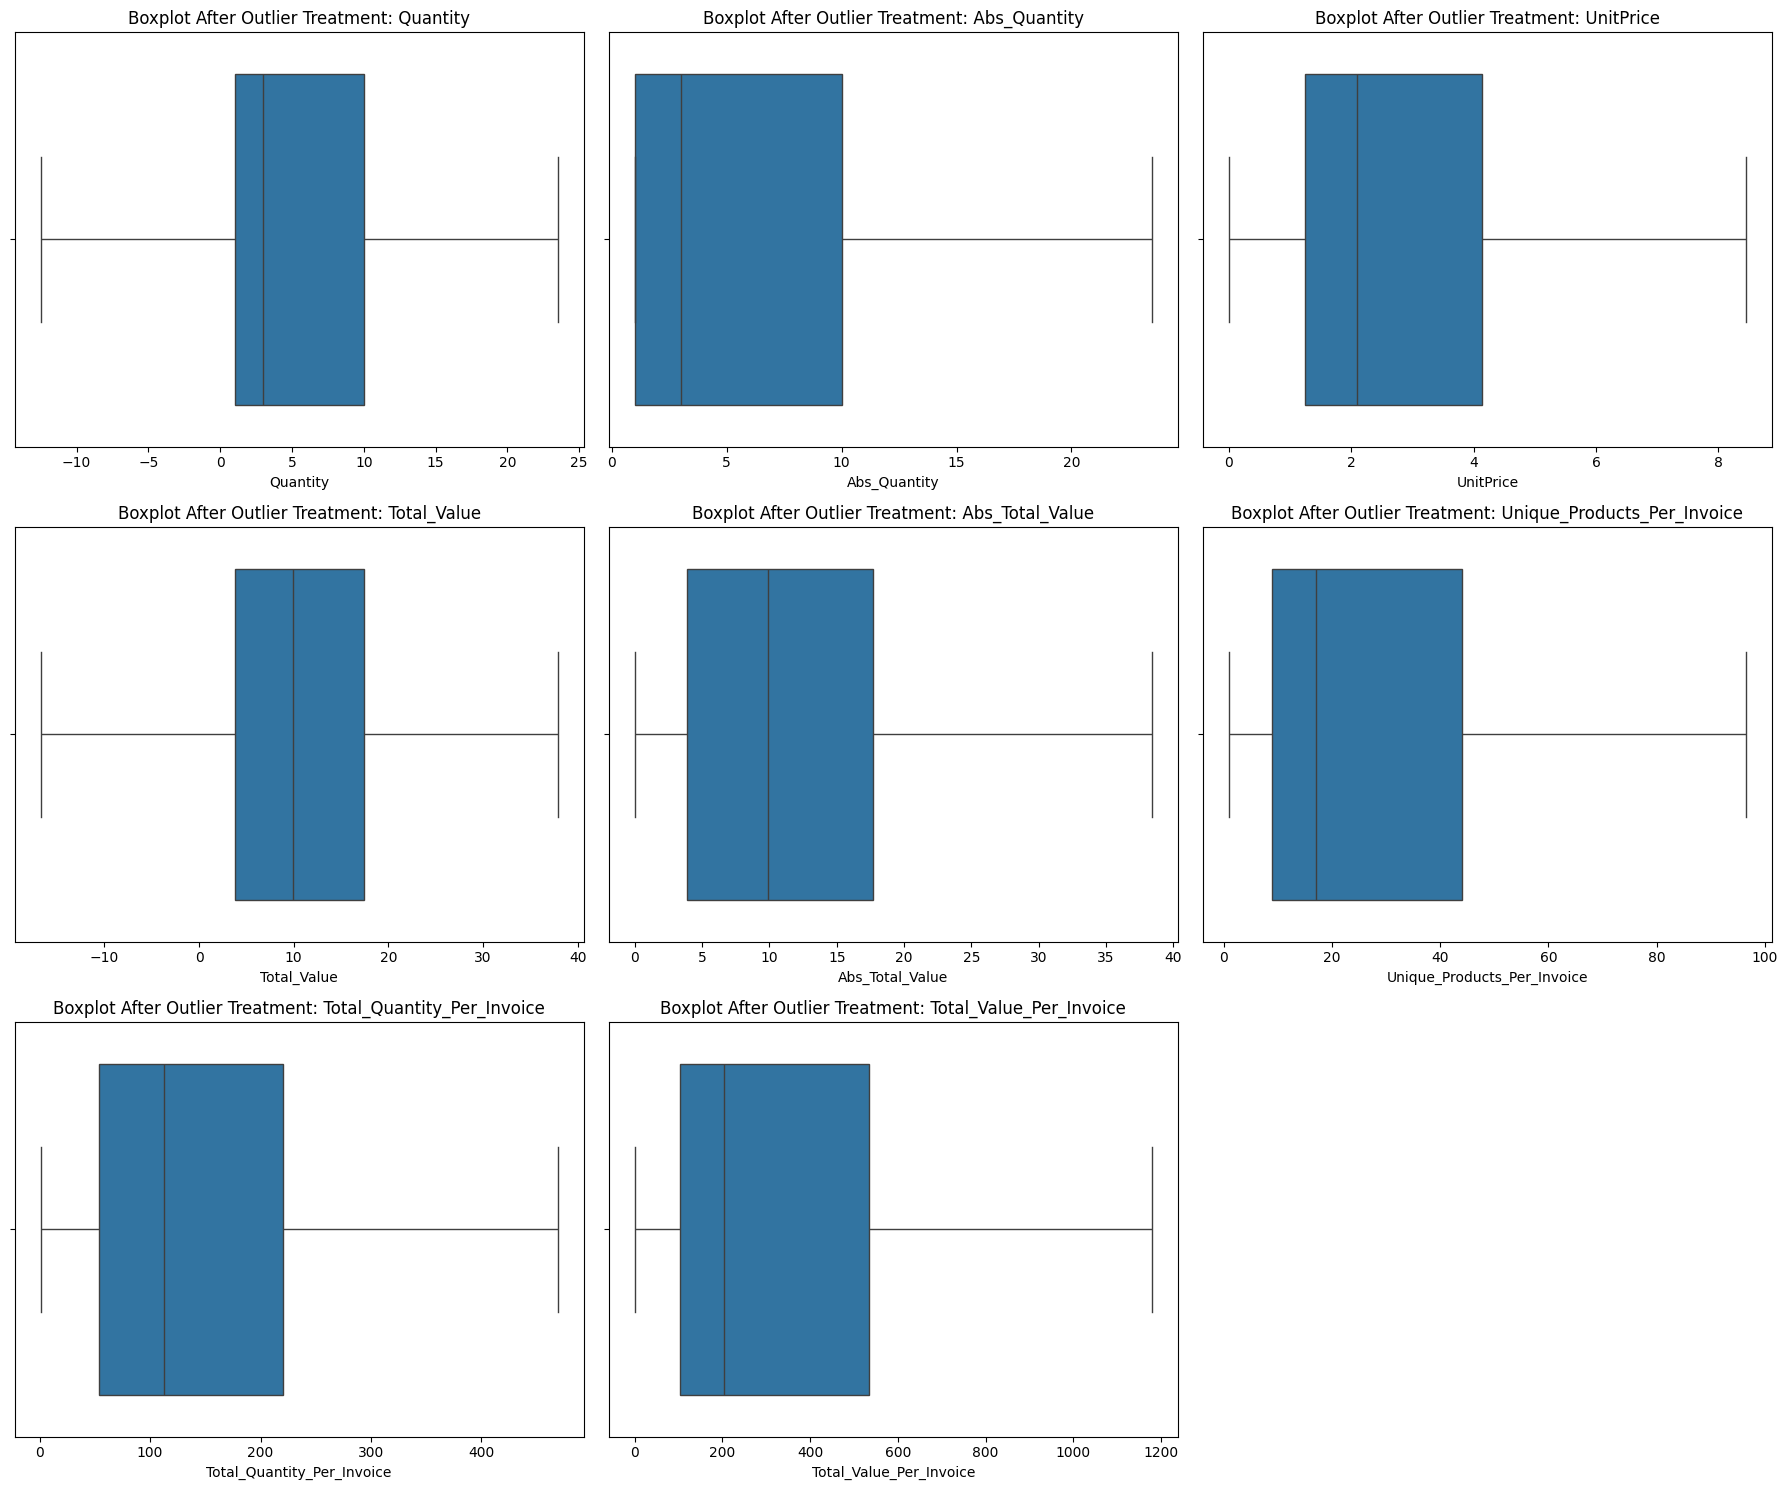

In [ ]:
# ============================================================
# STEP 6.6: VISUALIZE OUTLIERS AFTER TREATMENT
# ============================================================

# Determine the number of rows and columns for the subplot grid
num_cols = len(outlier_cols)
num_rows = math.ceil(num_cols / 3)  # Use 3 columns per row for a 3x3 or 4x4-like layout

plt.figure(figsize=(18, 5 * num_rows))
for i, col in enumerate(outlier_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(x=df_outlier[col])
    plt.title(f"Boxplot After Outlier Treatment: {col}")
    plt.xlabel(col)
plt.tight_layout()
plt.show()

##Step 6.7: Compare Summary Statistics Before and After Treatment

**Why this step?**

This shows how **extreme values changed** after capping while keeping the dataset size unchanged.

In [ ]:
# ============================================================
# STEP 6.7: COMPARE SUMMARY STATISTICS BEFORE AND AFTER
# ============================================================

print("Summary Before Outlier Treatment:")
display(df_features[outlier_cols].describe())

print("Summary After Outlier Treatment:")
display(df_outlier[outlier_cols].describe())

Summary Before Outlier Treatment:


,Quantity,Abs_Quantity,UnitPrice,Total_Value,Abs_Total_Value,Unique_Products_Per_Invoice,Total_Quantity_Per_Invoice,Total_Value_Per_Invoice
count,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000
mean,9.836768,10.983152,4.830858,17.992347,21.442357,41.087006,202.550189,518.045453
std,238.834705,238.784733,95.155051,272.258048,272.008076,58.073957,420.802607,955.164340
min,-74215.000000,1.000000,0.001000,-77183.600000,0.001000,1.000000,1.000000,0.390000
25%,1.000000,1.000000,1.250000,3.750000,3.900000,9.000000,54.000000,104.410000
50%,3.000000,3.000000,2.100000,9.870000,9.900000,17.000000,113.000000,202.630000
75%,10.000000,10.000000,4.130000,17.400000,17.700000,44.000000,220.000000,534.200000
max,74215.000000,74215.000000,17836.460000,77183.600000,77183.600000,412.000000,74215.000000,77183.600000


Summary After Outlier Treatment:


,Quantity,Abs_Quantity,UnitPrice,Total_Value,Abs_Total_Value,Unique_Products_Per_Invoice,Total_Quantity_Per_Invoice,Total_Value_Per_Invoice
count,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000,198239.000000
mean,6.531354,6.693862,2.978398,12.325146,12.752627,31.300670,160.986133,372.857291
std,7.258346,7.155334,2.405698,11.218067,11.032171,31.226559,141.271520,370.479934
min,-12.500000,1.000000,0.001000,-16.725000,0.001000,1.000000,1.000000,0.390000
25%,1.000000,1.000000,1.250000,3.750000,3.900000,9.000000,54.000000,104.410000
50%,3.000000,3.000000,2.100000,9.870000,9.900000,17.000000,113.000000,202.630000
75%,10.000000,10.000000,4.130000,17.400000,17.700000,44.000000,220.000000,534.200000
max,23.500000,23.500000,8.450000,37.875000,38.400000,96.500000,469.000000,1178.885000


## Step 6.8: Verify Dataset Shape and Target Distribution

**Why this step?**
Because **capping does not remove rows**, *the dataset size and target distribution should remain unchanged*.

In [ ]:
# ============================================================
# STEP 6.8: VERIFY SHAPE AND TARGET DISTRIBUTION
# ============================================================

print("Dataset shape after outlier treatment:", df_outlier.shape)

print("\nOrder Cancellation Distribution After Outlier Treatment:")
print(df_outlier["Order_Cancelled"].value_counts())

print("\nOrder Cancellation Percentage After Outlier Treatment:")
print(df_outlier["Order_Cancelled"].value_counts(normalize=True) * 100)

Dataset shape after outlier treatment: (198239, 21)

Order Cancellation Distribution After Outlier Treatment:
Order_Cancelled
0    194819
1      3420
Name: count, dtype: int64

Order Cancellation Percentage After Outlier Treatment:
Order_Cancelled
0    98.27481
1     1.72519
Name: proportion, dtype: float64


**Insight:**



> **Outlier detection** Outlier detection was performed using the **Interquartile Range (IQR) method.** Several numerical variables such as `Quantity`, `UnitPrice`, `Total Value`, `Total Quantity per Invoice`, and `Total Value per Invoice` **showed extreme values**. Since e-commerce datasets may contain **real high-value** or **bulk transactions**, outliers were *treated* using **capping** instead of deletion. This *reduced* the *influence of extreme values* while preserving all records. After treatment, the dataset size remained unchanged at 198,239 rows, and the cancellation distribution also remained stable.

**Key insight:**


> Outlier treatment improved the reliability of numerical features without changing the class distribution or removing important transaction records.





#Step 7: Prepare Final Modeling + Prevent Data Leakage

**Why this step is needed?**

Some columns should not go directly into the model

For example:

* `InvoiceNo` was used to create the target, so we should not use it as a model feature.
* `Quantity` and `Total_Value` contain negative values for cancelled orders, so they can directly reveal cancellation.
* This is call data **leakage**

If we keep leakage columns, the **model may look very accurate** but it will **not be a fair prediction model**.

**So now we will:**

1. Remove leakage/unnecessary columns
2. Keep useful business features
3. Reduce high-cardinality columns like `StockCode`
4. Prepare the final dataset for encoding and train-test split

## Step 7.1: Create Modeling Dataset

In [ ]:
# ============================================================
# STEP 7.1: CREATE MODELING DATASET
# Purpose:
# - Prepare final dataset for machine learning
# - Remove columns that may cause data leakage or are not useful directly
# ============================================================

df_model = df_outlier.copy()

print("Dataset shape before model preparation:", df_model.shape)

print("\nColumns available:")
print(df_model.columns.tolist())

Dataset shape before model preparation: (198239, 21)

Columns available:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Order_Cancelled', 'CustomerID_Missing', 'Abs_Quantity', 'Total_Value', 'Abs_Total_Value', 'Invoice_Year', 'Invoice_Month', 'Invoice_Day', 'Invoice_Hour', 'Invoice_Weekday', 'Unique_Products_Per_Invoice', 'Total_Quantity_Per_Invoice', 'Total_Value_Per_Invoice']


## Step 7.2: Handle High-Cardinality Product Column

In [ ]:
# ============================================================
# STEP 7.2: SIMPLIFY STOCKCODE
# Purpose:
# - StockCode has many unique product codes
# - Too many unique categories can make modeling difficult
# - We keep top 20 most frequent products and group others as "Other"
# ============================================================

top_stockcodes = df_model["StockCode"].value_counts().head(20).index

df_model["StockCode_Grouped"] = df_model["StockCode"].apply(
    lambda x: x if x in top_stockcodes else "Other"
)

print("Original unique StockCode count:", df_model["StockCode"].nunique())
print("Grouped StockCode count:", df_model["StockCode_Grouped"].nunique())

print("\nStockCode grouped distribution:")
print(df_model["StockCode_Grouped"].value_counts().head())

Original unique StockCode count: 3754
Grouped StockCode count: 21

StockCode grouped distribution:
StockCode_Grouped
Other     187239
22423        843
85123A       826
85099B       804
47566        624
Name: count, dtype: int64


## Step 7.3: Select Final Features

In [ ]:
# ============================================================
# STEP 7.3: SELECT FINAL FEATURES
# Purpose:
# - Remove leakage columns
# - Keep meaningful business and engineered features
# ============================================================

features_to_keep = [
    "UnitPrice",
    "Abs_Quantity",
    "Abs_Total_Value",
    "CustomerID_Missing",
    "Country",
    "StockCode_Grouped",
    "Invoice_Year",
    "Invoice_Month",
    "Invoice_Day",
    "Invoice_Hour",
    "Invoice_Weekday",
    "Unique_Products_Per_Invoice",
    "Total_Quantity_Per_Invoice",
    "Total_Value_Per_Invoice"
]

target = "Order_Cancelled"

df_model_final = df_model[features_to_keep + [target]].copy()

print("Final modeling dataset shape:", df_model_final.shape)

print("\nFinal selected columns:")
print(df_model_final.columns.tolist())

display(df_model_final.head())

Final modeling dataset shape: (198239, 15)

Final selected columns:
['UnitPrice', 'Abs_Quantity', 'Abs_Total_Value', 'CustomerID_Missing', 'Country', 'StockCode_Grouped', 'Invoice_Year', 'Invoice_Month', 'Invoice_Day', 'Invoice_Hour', 'Invoice_Weekday', 'Unique_Products_Per_Invoice', 'Total_Quantity_Per_Invoice', 'Total_Value_Per_Invoice', 'Order_Cancelled']


,UnitPrice,Abs_Quantity,Abs_Total_Value,CustomerID_Missing,Country,StockCode_Grouped,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,Invoice_Weekday,Unique_Products_Per_Invoice,Total_Quantity_Per_Invoice,Total_Value_Per_Invoice,Order_Cancelled
0,2.46,2.0,4.92,1,United Kingdom,Other,2011,12,6,16,1,96.5,469.0,1178.885,0
1,1.25,2.0,2.50,0,United Kingdom,Other,2011,5,23,12,0,16.0,43.0,100.700,0
2,0.85,3.0,2.55,0,United Kingdom,Other,2011,3,18,11,4,28.0,58.0,166.700,0
3,8.45,2.0,17.00,0,United Kingdom,Other,2011,7,7,18,3,5.0,23.0,90.750,0
4,6.75,1.0,6.75,0,United Kingdom,Other,2010,12,16,19,3,13.0,29.0,69.500,0


## Step 7.4: Check Final Dataset Before Encoding

In [ ]:
# ============================================================
# STEP 7.4: FINAL CHECK BEFORE ENCODING
# Purpose:
# - Verify missing values, data types, and target distribution
# ============================================================

print("Missing values in final modeling dataset:")
display(df_model_final.isnull().sum())

print("\nData types:")
print(df_model_final.dtypes)

print("\nTarget distribution:")
print(df_model_final["Order_Cancelled"].value_counts())

print("\nTarget percentage:")
print(df_model_final["Order_Cancelled"].value_counts(normalize=True) * 100)

Missing values in final modeling dataset:


,0
UnitPrice,0
Abs_Quantity,0
Abs_Total_Value,0
CustomerID_Missing,0
Country,0
StockCode_Grouped,0
Invoice_Year,0
Invoice_Month,0
Invoice_Day,0
Invoice_Hour,0



Data types:
UnitPrice                      float64
Abs_Quantity                   float64
Abs_Total_Value                float64
CustomerID_Missing               int64
Country                         object
StockCode_Grouped               object
Invoice_Year                     int32
Invoice_Month                    int32
Invoice_Day                      int32
Invoice_Hour                     int32
Invoice_Weekday                  int32
Unique_Products_Per_Invoice    float64
Total_Quantity_Per_Invoice     float64
Total_Value_Per_Invoice        float64
Order_Cancelled                  int64
dtype: object

Target distribution:
Order_Cancelled
0    194819
1      3420
Name: count, dtype: int64

Target percentage:
Order_Cancelled
0    98.27481
1     1.72519
Name: proportion, dtype: float64


**Report:**
The dataset after model preparation contained **198,239 rows** and **15 columns**. The final dataset had **no missing values**, which means it was ready for the next preprocessing stage.

Some columns were removed because they were not suitable for model training. `InvoiceNo` was removed because it is only an **identifier**. `InvoiceDate` was not used directly because time-based features had already been extracted from it. `Quantity` and `Total_Value` were **removed** because their negative values directly indicate cancellations and could create data leakage. Instead, absolute-value features such as `Abs_Quantity` and `Abs_Total_Value` were used.

The StockCode column originally had** 3,754 unique product codes**, which would make encoding very large and complex. To *reduce dimensionality*, the **top 20 most frequent product codes were kept**, and all *remaining products were grouped into an "Other" category*. This reduced the product category count to 21, making the feature more suitable for machine learning



**Insight:**

The final modeling dataset contains meaningful business and behavioral features, including `order value`, `order quantity`, `customer identification status`, `country`, `product group`, and `time-based features`. This makes the dataset suitable for predicting order cancellation risk.

A key finding from this step is that the target variable **remained highly imbalanced**, with only about **1.73% cancelled orders** and **98.27% normal orders**. This confirms that model *evaluation should not rely only on* **accuracy**. Metrics such as `precision`, `recall`, `F1-score`, and `ROC-AUC` will be more important.

#Step 8: Encoding + Train-Test Split + Scaling
**Why this step is needed?**

Machine Learning models cannot directly understand text categories like:

* `country`
* `StockCode_Grouped`

So we must **convert** `categorical variables` into `numerical format` using `one-hot encoding`.

**Then we split the dataset into:**

* Training data → used to train the model
* Testing data → used to evaluate the model

Because the target is **highly imbalanced**, we will use **stratified splitting** so the train and test sets keep the same cancellation ratio.

Finally, we **scale numerical features** using **StandardScaler**, because models like Logistic Regression and KNN are sensitive to feature scale.

## STEP 8.1: ENCODING CATEGORICAL VARIABLES

In [ ]:
# ============================================================
# STEP 8.1: ENCODING CATEGORICAL VARIABLES
# Purpose:
# - Convert text/categorical features into numerical format
# - Required for machine learning models
# ============================================================

df_encoded = pd.get_dummies(
    df_model_final,
    columns=["Country", "StockCode_Grouped"],
    drop_first=True
)

print("Dataset shape before encoding:", df_model_final.shape)
print("Dataset shape after encoding:", df_encoded.shape)

print("\nFirst 5 rows after encoding:")
display(df_encoded.head())

Dataset shape before encoding: (198239, 15)
Dataset shape after encoding: (198239, 70)

First 5 rows after encoding:


,UnitPrice,Abs_Quantity,Abs_Total_Value,CustomerID_Missing,Invoice_Year,Invoice_Month,Invoice_Day,Invoice_Hour,Invoice_Weekday,Unique_Products_Per_Invoice,...,StockCode_Grouped_22720,StockCode_Grouped_22960,StockCode_Grouped_23203,StockCode_Grouped_23298,StockCode_Grouped_47566,StockCode_Grouped_84879,StockCode_Grouped_85099B,StockCode_Grouped_85123A,StockCode_Grouped_Other,StockCode_Grouped_POST
0,2.46,2.0,4.92,1,2011,12,6,16,1,96.5,...,False,False,False,False,False,False,False,False,True,False
1,1.25,2.0,2.50,0,2011,5,23,12,0,16.0,...,False,False,False,False,False,False,False,False,True,False
2,0.85,3.0,2.55,0,2011,3,18,11,4,28.0,...,False,False,False,False,False,False,False,False,True,False
3,8.45,2.0,17.00,0,2011,7,7,18,3,5.0,...,False,False,False,False,False,False,False,False,True,False
4,6.75,1.0,6.75,0,2010,12,16,19,3,13.0,...,False,False,False,False,False,False,False,False,True,False


## STEP 8.2: SEPARATE FEATURES AND TARGET

In [ ]:
# ============================================================
# STEP 8.2: SEPARATE FEATURES AND TARGET
# Purpose:
# - X contains independent variables/features
# - y contains target variable Order_Cancelled
# ============================================================

X = df_encoded.drop("Order_Cancelled", axis=1)
y = df_encoded["Order_Cancelled"]

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Feature matrix shape: (198239, 69)
Target variable shape: (198239,)

Target distribution:
Order_Cancelled
0    194819
1      3420
Name: count, dtype: int64

Target percentage:
Order_Cancelled
0    98.27481
1     1.72519
Name: proportion, dtype: float64


## STEP 8.3: TRAIN-TEST SPLIT

In [ ]:
# ============================================================
# STEP 8.3: TRAIN-TEST SPLIT
# Purpose:
# - Split data into training and testing sets
# - Stratify keeps cancellation ratio same in both sets
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Training feature shape: (158591, 69)
Testing feature shape: (39648, 69)

Training target distribution:
Order_Cancelled
0    155855
1      2736
Name: count, dtype: int64
Order_Cancelled
0    98.274808
1     1.725192
Name: proportion, dtype: float64

Testing target distribution:
Order_Cancelled
0    38964
1      684
Name: count, dtype: int64
Order_Cancelled
0    98.274818
1     1.725182
Name: proportion, dtype: float64


## STEP 8.4: FEATURE SCALING

In [ ]:
# ============================================================
# STEP 8.4: FEATURE SCALING
# Purpose:
# - Standardize numerical features
# - Fit scaler only on training data to avoid data leakage
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled training data shape: (158591, 69)
Scaled testing data shape: (39648, 69)


## STEP 8.5: SAVE PROCESSED TRAIN-TEST DATA

In [ ]:
# ============================================================
# STEP 8.5: SAVE PROCESSED TRAIN-TEST DATA
# Purpose:
# - Save final processed datasets for future use
# ============================================================

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_df["Order_Cancelled"] = y_train.reset_index(drop=True)
X_test_df["Order_Cancelled"] = y_test.reset_index(drop=True)

X_train_df.to_csv("processed_train_data.csv", index=False)
X_test_df.to_csv("processed_test_data.csv", index=False)

print("Processed train and test datasets saved successfully.")
print("Files created:")
print("1. processed_train_data.csv")
print("2. processed_test_data.csv")

Processed train and test datasets saved successfully.
Files created:
1. processed_train_data.csv
2. processed_test_data.csv


**Report Insight:**

Categorical variables such as `Country` and `grouped StockCode` were **converted** into **numerical format** using `one-hot encoding`. After encoding, the dataset expanded from **15 to 70 columns**. The feature matrix contained **69 predictor variables**, while *Order_Cancelled* was used as the **target variable**. The dataset was split into training and testing sets using an **80:20 ratio** with **stratified sampling** to preserve the original cancellation distribution in both subsets. **Feature scaling** was then applied using `StandardScaler`. The scaler was fitted only on the training data and later applied to the testing data to prevent data leakage. Finally, the processed train and test datasets were saved for future modeling and evaluation.

# Step 9: Handle Class Imbalance Before Model Training

Since cancellations are only about **1.7%**, we should handle imbalance before training.

We'll start with the safest method: `Class Weighting`

**Why this first:**

* No extra installation needed
* Keeps original data unchanged
* Works well with Logistic Regression, Decision Tree, and Random Forest
* Good for explaining in report

**Why we are doing this?**

Because **cancelled orders** are `rare`, **normal models** may focus too much on `predicting Normal orders`.

`class_weight="balanced"` tells the model:

> Give more importance to the minority class, which is cancelled orders.

This helps the model pay more attention to cancellations.

**What we are trying to achieve?**

We want a model that can **identify cancelled orders better**.

For this project, **recall** is very important because:

> If the model misses cancelled orders, the business cannot take early action.

## STEP 9.1: CHECK CLASS IMBALANCE BEFORE MODELING

Training Target Distribution:
Order_Cancelled
0    155855
1      2736
Name: count, dtype: int64

Training Target Percentage:
Order_Cancelled
0    98.274808
1     1.725192
Name: proportion, dtype: float64


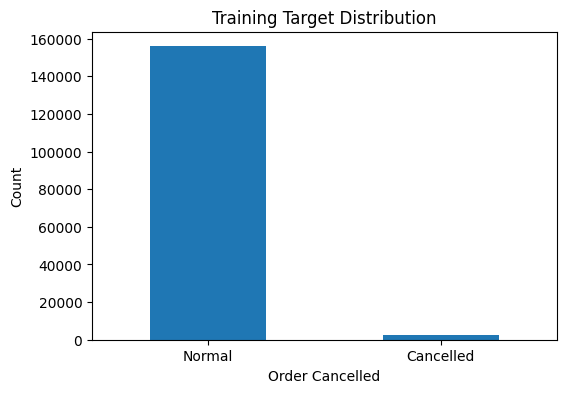

In [ ]:
# ============================================================
# STEP 9.1: CHECK CLASS IMBALANCE BEFORE MODELING
# ============================================================

print("Training Target Distribution:")
print(y_train.value_counts())

print("\nTraining Target Percentage:")
print(y_train.value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
y_train.value_counts().plot(kind="bar")
plt.title("Training Target Distribution")
plt.xlabel("Order Cancelled")
plt.ylabel("Count")
plt.xticks([0, 1], ["Normal", "Cancelled"], rotation=0)
plt.show()

## STEP 9.2: MODEL TRAINING WITH CLASS WEIGHTING

In [ ]:
# ============================================================
# STEP 9.2: MODEL TRAINING WITH CLASS WEIGHTING
# ============================================================

models_weighted = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

weighted_results = []

for model_name, model in models_weighted.items():

    print("\n======================================")
    print("Training Model:", model_name)
    print("======================================")

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    weighted_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Training Model: Logistic Regression
Accuracy: 0.8275070621468926
Precision: 0.08361520768502233
Recall: 0.9035087719298246
F1 Score: 0.15306501547987617
ROC-AUC: 0.9496795962805072

Confusion Matrix:
[[32191  6773]
 [   66   618]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.90     38964
           1       0.08      0.90      0.15       684

    accuracy                           0.83     39648
   macro avg       0.54      0.86      0.53     39648
weighted avg       0.98      0.83      0.89     39648


Training Model: Decision Tree
Accuracy: 0.99170197740113
Precision: 0.7786499215070644
Recall: 0.7251461988304093
F1 Score: 0.7509462528387585
ROC-AUC: 0.8607810718666083

Confusion Matrix:
[[38823   141]
 [  188   496]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38964
           1       0.78      0.73      0.75       684

    acc

## STEP 9.3: COMPARE WEIGHTED MODEL RESULTS

Weighted Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.827507,0.083615,0.903509,0.153065,0.949680
1,Decision Tree,0.991702,0.778650,0.725146,0.750946,0.860781
2,Random Forest,0.991626,0.863636,0.611111,0.715753,0.995670


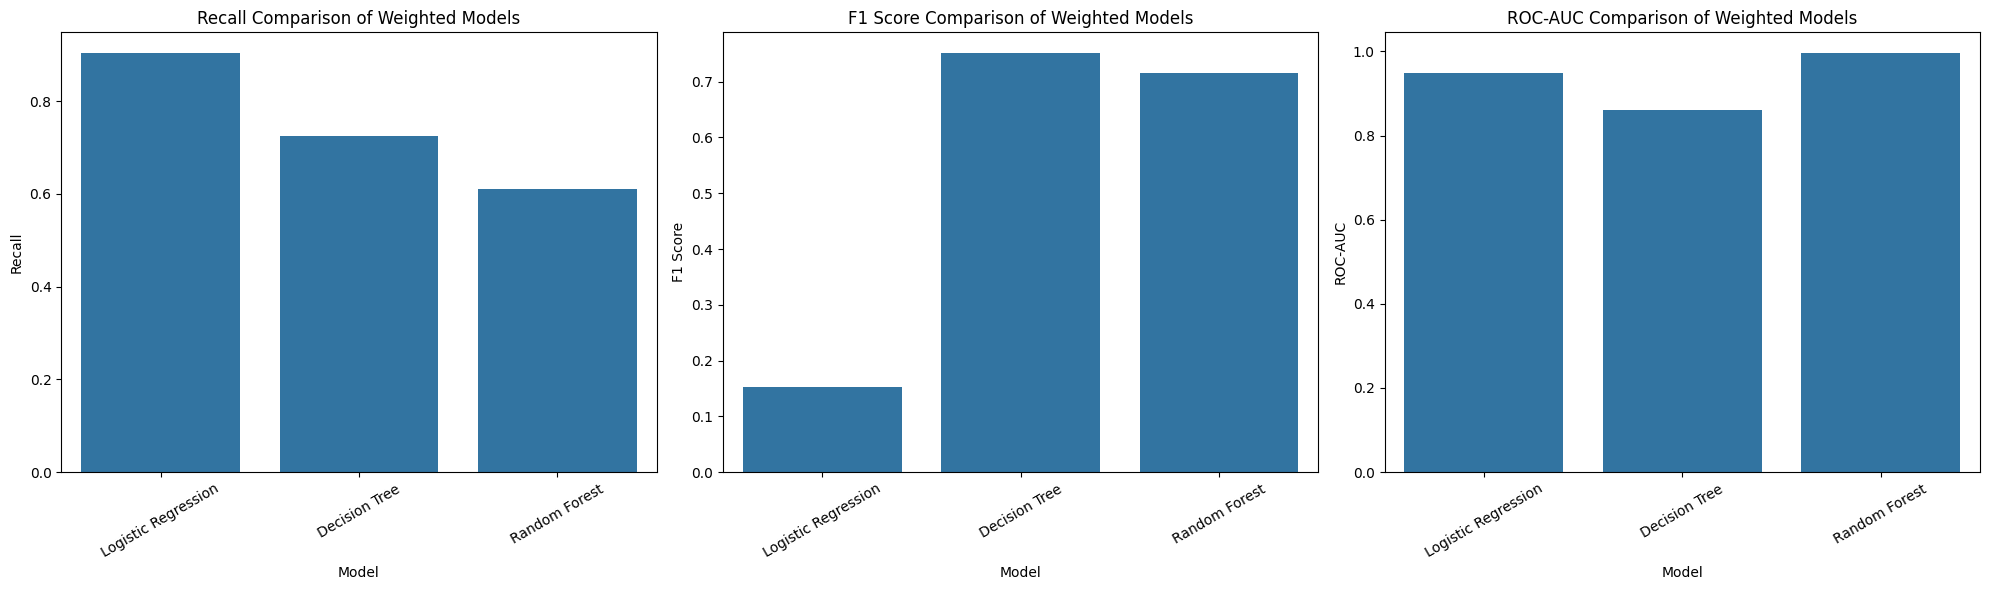

In [ ]:
# ============================================================
# STEP 9.3: COMPARE WEIGHTED MODEL RESULTS
# ============================================================

weighted_results_df = pd.DataFrame(weighted_results)

print("Weighted Model Comparison:")
display(weighted_results_df)

plt.figure(figsize=(20, 6)) # Adjust overall figure size for 1x3 plots

plt.subplot(1, 3, 1) # First subplot for Recall
sns.barplot(x="Model", y="Recall", data=weighted_results_df)
plt.title("Recall Comparison of Weighted Models")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=30)

plt.subplot(1, 3, 2) # Second subplot for F1 Score
sns.barplot(x="Model", y="F1 Score", data=weighted_results_df)
plt.title("F1 Score Comparison of Weighted Models")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)

plt.subplot(1, 3, 3) # Third subplot for ROC-AUC
sns.barplot(x="Model", y="ROC-AUC", data=weighted_results_df)
plt.title("ROC-AUC Comparison of Weighted Models")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=30)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

#

**Report:**
Since cancelled orders represent only around **1.73%** of the training data, class imbalance was addressed using **class weighting**. Three weighted models were trained: `Logistic Regression`, `Decision Tree`, and `Random Forest`. Logistic Regression achieved the **highest recall**, meaning it identified most cancelled orders, but its **precision was very low**, resulting in many **false cancellation alerts**. `Random Forest` achieved the **highest precision** and **ROC-AUC**, indicating strong confidence when predicting cancellations, but it **missed more cancelled orders**. `Decision Tree` provided the **best balance** between **precision** and **recall**, achieving the **highest F1-score**. Therefore, **Decision Tree** was the **most balanced model** *at this stage*.


**Insight:**

`Class weighting` helped the models pay **more attention** to the **minority cancellation class**. The results show that different models behave differently: `Logistic Regression` prioritizes **detecting cancellations**, `Random Forest` prioritizes **precision**, and `Decision Tree` provides the **best overall balance**. Because the dataset is highly imbalanced, **F1-score** and **recall** are *more meaningful* than accuracy alone.


# Step 10: Model Optimization

We will optimize the two strongest models from Step 9:

1. Decision Tree — best F1-score/balanced performance
2. Random Forest — best precision and ROC-AUC

## Step 10.1 Optimize Decision Tree

In [ ]:
# ============================================================
# STEP 10.1: DECISION TREE OPTIMIZATION
# Purpose:
# - Improve Decision Tree performance using GridSearchCV
# - Tune key parameters to reduce overfitting and improve F1-score
# ============================================================

dt_param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid=dt_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)

best_dt = dt_grid.best_estimator_

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

y_pred_dt_opt = best_dt.predict(X_test_scaled)
y_prob_dt_opt = best_dt.predict_proba(X_test_scaled)[:, 1]

print("\nOptimized Decision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_opt))
print("Precision:", precision_score(y_test, y_pred_dt_opt))
print("Recall:", recall_score(y_test, y_pred_dt_opt))
print("F1 Score:", f1_score(y_test, y_pred_dt_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt_opt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_opt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_opt))

Best Decision Tree Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}

Optimized Decision Tree Performance:
Accuracy: 0.9914497578692494
Precision: 0.7290836653386454
Recall: 0.8026315789473685
F1 Score: 0.7640918580375783
ROC-AUC: 0.8994567860211047

Confusion Matrix:
[[38760   204]
 [  135   549]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     38964
           1       0.73      0.80      0.76       684

    accuracy                           0.99     39648
   macro avg       0.86      0.90      0.88     39648
weighted avg       0.99      0.99      0.99     39648



## Step 10.2: Optimize Random Forest

In [50]:
# ============================================================
# STEP 10.2: RANDOM FOREST OPTIMIZATION
# Purpose:
# - Improve Random Forest performance using GridSearchCV
# - Tune tree depth, number of estimators, and sample rules
# ============================================================

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

y_pred_rf_opt = best_rf.predict(X_test_scaled)
y_prob_rf_opt = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\nOptimized Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_opt))
print("Precision:", precision_score(y_test, y_pred_rf_opt))
print("Recall:", recall_score(y_test, y_pred_rf_opt))
print("F1 Score:", f1_score(y_test, y_pred_rf_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_opt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_opt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_opt))

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Optimized Random Forest Performance:
Accuracy: 0.9919541969330105
Precision: 0.8130360205831904
Recall: 0.6929824561403509
F1 Score: 0.7482241515390686
ROC-AUC: 0.9962528013562977

Confusion Matrix:
[[38855   109]
 [  210   474]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     38964
           1       0.81      0.69      0.75       684

    accuracy                           0.99     39648
   macro avg       0.90      0.85      0.87     39648
weighted avg       0.99      0.99      0.99     39648



## Compare Optimized Models

## Step 10.3: Compare Optimized Models

Optimized Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Optimized Decision Tree,0.991450,0.729084,0.802632,0.764092,0.899457
1,Optimized Random Forest,0.991954,0.813036,0.692982,0.748224,0.996253


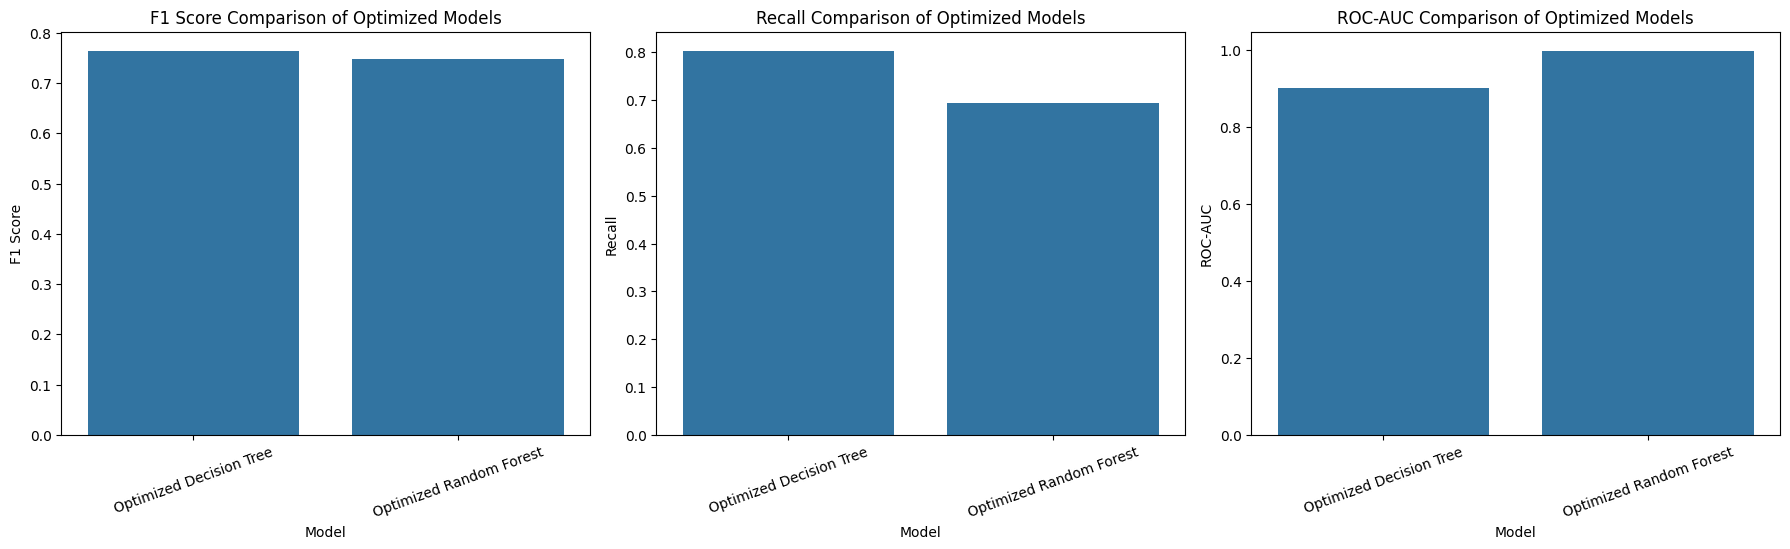

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP 10.3: OPTIMIZED MODEL COMPARISON
# Purpose:
# - Compare optimized Decision Tree and Random Forest
# ============================================================

optimized_results = [
    {
        "Model": "Optimized Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt_opt),
        "Precision": precision_score(y_test, y_pred_dt_opt),
        "Recall": recall_score(y_test, y_pred_dt_opt),
        "F1 Score": f1_score(y_test, y_pred_dt_opt),
        "ROC-AUC": roc_auc_score(y_test, y_prob_dt_opt)
    },
    {
        "Model": "Optimized Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf_opt),
        "Precision": precision_score(y_test, y_pred_rf_opt),
        "Recall": recall_score(y_test, y_pred_rf_opt),
        "F1 Score": f1_score(y_test, y_pred_rf_opt),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf_opt)
    }
]

optimized_results_df = pd.DataFrame(optimized_results)

print("Optimized Model Comparison:")
display(optimized_results_df)

# Create a 3x3 grid for the plots
plt.figure(figsize=(18, 15)) # Adjust overall figure size for a 3x3 layout

plt.subplot(3, 3, 1) # First subplot for F1 Score
sns.barplot(x="Model", y="F1 Score", data=optimized_results_df)
plt.title("F1 Score Comparison of Optimized Models")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)

plt.subplot(3, 3, 2) # Second subplot for Recall
sns.barplot(x="Model", y="Recall", data=optimized_results_df)
plt.title("Recall Comparison of Optimized Models")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=20)

plt.subplot(3, 3, 3) # Third subplot for ROC-AUC
sns.barplot(x="Model", y="ROC-AUC", data=optimized_results_df)
plt.title("ROC-AUC Comparison of Optimized Models")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=20)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

**Report:**

Model optimization was performed using **GridSearchCV** for Decision Tree and Random Forest models. The `Decision Tree` achieved a **recall** of **80.26%** and an **F1-score of 76.41%**, while `Random Forest` achieved **higher precision of 81.30%** and **ROC-AUC of 99.63%**. Although **Random Forest was more precise**, the optimized `Decision Tree` identified a **larger proportion of actual cancelled orders**. Since the project goal is to **detect cancellation risk early**, recall and F1-score were prioritized. Therefore, `the optimized Decision Tree` was **selected** as the final model.

**Insight:**

Optimization improved model performance and helped identify the best model for the business objective. The `optimized Decision Tree` provides the **strongest balance** for detecting **cancellation risk**, while **Random Forest** is better when the business wants **fewer false alerts**.

# Step 11: Final Model Evaluation, Feature Importance & Business Conclusion

**We selected:**

> Final Model: Optimized Decision Tree

Now we will evaluate it clearly and extract business meaning.

## Step 11.1: Final Confusion Matrix Visualization

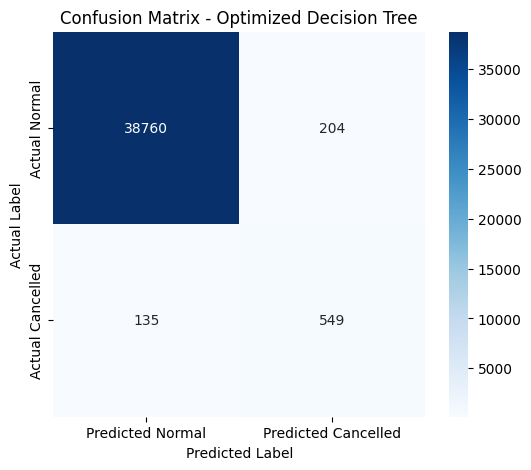

Confusion Matrix:
[[38760   204]
 [  135   549]]


In [53]:
# ============================================================
# STEP 11.1: FINAL CONFUSION MATRIX VISUALIZATION
# Final Model: Optimized Decision Tree
# ============================================================

final_model = best_dt
final_y_pred = y_pred_dt_opt
final_y_prob = y_prob_dt_opt

cm = confusion_matrix(y_test, final_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Cancelled"],
    yticklabels=["Actual Normal", "Actual Cancelled"]
)

plt.title("Confusion Matrix - Optimized Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print("Confusion Matrix:")
print(cm)

**Insight:**

| Actual                | Predicted                      |  Count |
| --------------------- | ------------------------------ | -----: |
| Normal → Normal       | Correct prediction             | 38,760 |
| Normal → Cancelled    | False alarm                    |    204 |
| Cancelled → Normal    | Missed cancellation            |    135 |
| Cancelled → Cancelled | Correct cancellation detection |    549 |


**Business Interpretation:**

The model successfully identified:
* **549** cancelled orders

while missing only:

* **135** cancelled orders

This is strong performance for a highly imbalanced dataset.

## STEP 11.2: FINAL CLASSIFICATION REPORT

In [54]:
# ============================================================
# STEP 11.2: FINAL CLASSIFICATION REPORT
# ============================================================

print("Final Model Classification Report:")
print(classification_report(y_test, final_y_pred))

print("Final Model Metrics:")
print("Accuracy:", accuracy_score(y_test, final_y_pred))
print("Precision:", precision_score(y_test, final_y_pred))
print("Recall:", recall_score(y_test, final_y_pred))
print("F1 Score:", f1_score(y_test, final_y_pred))
print("ROC-AUC:", roc_auc_score(y_test, final_y_prob))

Final Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     38964
           1       0.73      0.80      0.76       684

    accuracy                           0.99     39648
   macro avg       0.86      0.90      0.88     39648
weighted avg       0.99      0.99      0.99     39648

Final Model Metrics:
Accuracy: 0.9914497578692494
Precision: 0.7290836653386454
Recall: 0.8026315789473685
F1 Score: 0.7640918580375783
ROC-AUC: 0.8994567860211047


**Insights:**

| Metric    |  Value |
| --------- | -----: |
| Accuracy  | 99.14% |
| Precision | 72.91% |
| Recall    | 80.26% |
| F1 Score  | 76.41% |
| ROC-AUC   | 89.95% |

**Recall = 80.26%**

Meaning:

>The model can successfully detect about 80% of cancellation cases before they happen.

This creates **strong business value**.

## STEP 11.3: ROC CURVE FOR FINAL MODEL

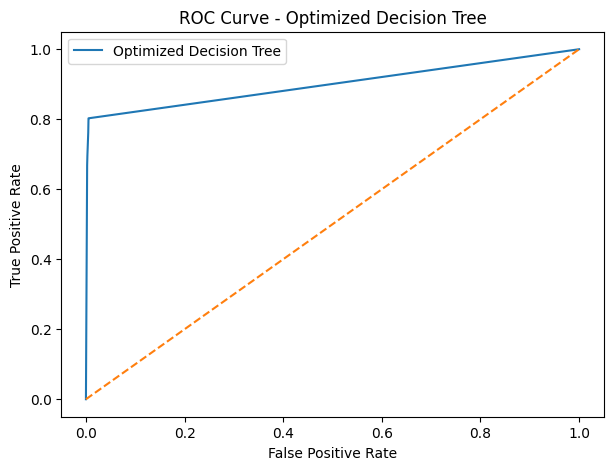

ROC-AUC Score: 0.8994567860211047


In [55]:
# ============================================================
# STEP 11.3: ROC CURVE FOR FINAL MODEL
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, final_y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Optimized Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Optimized Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, final_y_prob))

**Analysis:**
Your ROC curve is clearly above the diagonal baseline.

**ROC-AUC ≈ 0.90 indicates:**

* strong class separation
* strong predictive capability
* reliable risk classification

## STEP 11.4: FEATURE IMPORTANCE ANALYSIS

Top 15 Important Features:


,Feature,Importance
9,Unique_Products_Per_Invoice,0.607086
10,Total_Quantity_Per_Invoice,0.105039
11,Total_Value_Per_Invoice,0.089511
6,Invoice_Day,0.048702
5,Invoice_Month,0.035189
7,Invoice_Hour,0.034343
8,Invoice_Weekday,0.028093
45,Country_USA,0.021851
0,UnitPrice,0.005504
2,Abs_Total_Value,0.004713


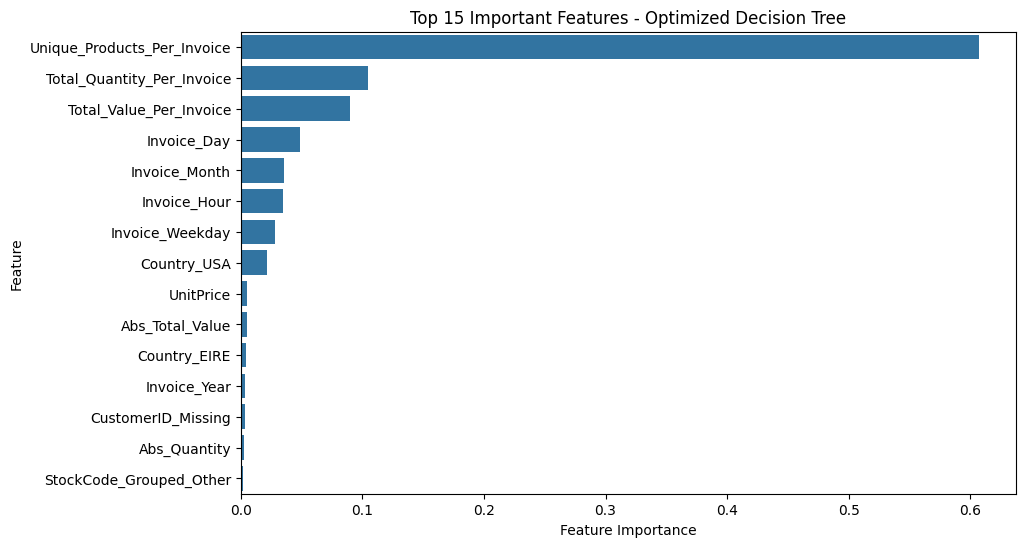

In [56]:
# ============================================================
# STEP 11.4: FEATURE IMPORTANCE ANALYSIS
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(feature_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features - Optimized Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

**🎯Most important feature:**  `Unique_Products_Per_Invoice`

**Importance ≈ 0.61**

This dominates all other features.

**Business Insight:**

Orders *containing many different products* are s**trongly associated with cancellation behavior**.

Possible business reasons:

* 📍customers change their minds on **large mixed-product orders**
* 📍complex orders **increase operational issues**
* 📍multi-product carts may represent **uncertain purchase intent**

**Other important features:**
| Feature                    | Business Meaning                              |
| -------------------------- | --------------------------------------------- |
| Total_Quantity_Per_Invoice | Larger orders behave differently              |
| Total_Value_Per_Invoice    | High-value orders influence cancellation risk |
| Invoice_Day / Month / Hour | Time affects cancellation behavior            |
| Country_USA                | Geographic patterns affect cancellation       |
| CustomerID_Missing         | Guest/anonymous behavior affects risk         |


## STEP 11.5: FINAL PREDICTION TABLE

In [57]:
# ============================================================
# STEP 11.5: FINAL PREDICTION TABLE
# ============================================================

final_predictions = X_test.copy()

final_predictions["Actual_Order_Cancelled"] = y_test.values
final_predictions["Predicted_Order_Cancelled"] = final_y_pred
final_predictions["Cancellation_Probability"] = final_y_prob

def cancellation_risk(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

final_predictions["Risk_Level"] = final_predictions["Cancellation_Probability"].apply(cancellation_risk)

final_predictions["Actual_Order_Cancelled"] = final_predictions["Actual_Order_Cancelled"].map({
    0: "Normal",
    1: "Cancelled"
})

final_predictions["Predicted_Order_Cancelled"] = final_predictions["Predicted_Order_Cancelled"].map({
    0: "Normal",
    1: "Cancelled"
})

display(final_predictions[[
    "Actual_Order_Cancelled",
    "Predicted_Order_Cancelled",
    "Cancellation_Probability",
    "Risk_Level"
]].head(20))

,Actual_Order_Cancelled,Predicted_Order_Cancelled,Cancellation_Probability,Risk_Level
55010,Normal,Normal,0.0,Low Risk
5791,Normal,Normal,0.0,Low Risk
126386,Normal,Normal,0.0,Low Risk
112244,Normal,Normal,0.0,Low Risk
8353,Normal,Normal,0.0,Low Risk
74477,Normal,Normal,0.0,Low Risk
181332,Normal,Normal,0.0,Low Risk
163812,Normal,Normal,0.0,Low Risk
74626,Normal,Normal,0.0,Low Risk
143397,Normal,Normal,0.0,Low Risk


**Insight:**

**Risk Prediction Table**

Our model now produces:

* predicted status
* cancellation probability
* risk category

This makes the project practical and business-oriented.

## STEP 11.6: RISK LEVEL SUMMARY

Risk Level Distribution:
Risk_Level
Low Risk     38895
High Risk      753
Name: count, dtype: int64


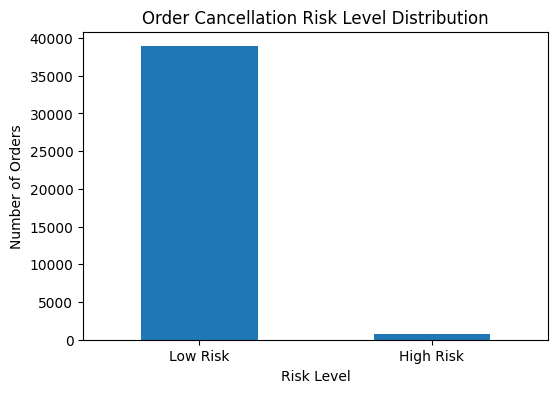

In [58]:
# ============================================================
# STEP 11.6: RISK LEVEL SUMMARY
# ============================================================

print("Risk Level Distribution:")
print(final_predictions["Risk_Level"].value_counts())

plt.figure(figsize=(6, 4))
final_predictions["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Order Cancellation Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

**Risk Distribution Analysis:**
| Risk Level |  Count |
| ---------- | -----: |
| Low Risk   | 38,895 |
| High Risk  |    753 |

This means the model identifies a **smaller group of potentially risky orders** for *further review*.

## STEP 11.7: SAVE FINAL OUTPUTS

In [59]:
# ============================================================
# STEP 11.7: SAVE FINAL OUTPUTS
# ============================================================

final_predictions.to_csv("final_order_cancellation_predictions.csv", index=False)
feature_importance.to_csv("final_feature_importance.csv", index=False)
optimized_results_df.to_csv("optimized_model_comparison.csv", index=False)

print("Final output files saved successfully:")
print("1. final_order_cancellation_predictions.csv")
print("2. final_feature_importance.csv")
print("3. optimized_model_comparison.csv")

Final output files saved successfully:
1. final_order_cancellation_predictions.csv
2. final_feature_importance.csv
3. optimized_model_comparison.csv


**Final Business Conclusion:**

This ML Project proves that-

> E-commerce order cancellation risk can be predicted effectively using transactional, behavioral, and temporal features.

The optimized Decision Tree model achieved **strong predictive performance** and can help businesses:

* 📍identify risky orders early
* 📍reduce cancellation-related losses
* 📍improve inventory planning
* 📍optimize customer support
* 📍improve operational efficiency
